Sunday 21 June
This is in response to Gabe's feedback on Friday.
I've already run alignments for RS, CUT3R and then today did mega sam. But will do more for good comparisons. Taking cells from MASTER SWITCH

In [ ]:
#loading
%load_ext autoreload
%autoreload 2
from pathlib import Path
print(Path.cwd())


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [121]:
#UCL LAB CLUSTERS
from pathlib import Path
import sys

# find the repo root by walking up until we hit a directory containing src/A_Config.py,
# rather than trusting cwd (VS Code's Jupyter kernel cwd often isn't the notebook's own folder)
project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    if project_root == project_root.parent:
        raise RuntimeError("couldn't find repo root (src/A_Config.py) above cwd")
    project_root = project_root.parent

sys.path.insert(0, str(project_root / "src"))
print("project_root:", project_root)

from F_post_recon_processing import load_reality_scan_trace, load_VGGT_O_trace
from F_post_recon_processing import load_cut3r_trace, load_megasam_trace
from G_transforms_alignments import umeyama_align

project_root: /cs/student/project_msc/2025/cgvi/dbarker


In [ ]:
'''
from pathlib import Path
import sys

#project_root = Path.cwd().parent      # up from experiments/ to MScPROJECT_LOCAL
#print(project_root)
sys.path.insert(0, str(project_root / "src"))   # down into src/
from F_post_recon_processing import load_reality_scan_trace, load_VGGT_O_trace
from F_post_recon_processing import load_cut3r_trace, load_cut3r_trace_v2, load_megasam_trace
from G_transforms_alignments import umeyama_align'''

01 WALK

In [ ]:
#set up
case_name = "01_walk"
case_dir     = project_root / "Data" / case_name
out_dir     =   project_root / "Data" / case_name / "080_Experiments"

INITIAL 50 RESULTS FROM WALK_01 - low res images


/cs/student/project_msc/2025/cgvi/dbarker/Data/01_walk
{0: array([-0.00059826, -0.0002887 ,  0.00161247], dtype=float32), 1: array([-0.00654796, -0.00852484,  0.0125241 ], dtype=float32), 2: array([-0.00636884, -0.01183967,  0.0513218 ], dtype=float32), 3: array([-0.01935649, -0.0125712 ,  0.08244719], dtype=float32), 4: array([-0.02026151, -0.01450352,  0.11977598], dtype=float32), 5: array([-0.02841841, -0.01932735,  0.16392022], dtype=float32), 6: array([-0.03717248, -0.02398662,  0.21909244], dtype=float32), 7: array([-0.03165304, -0.02587129,  0.24039155], dtype=float32), 8: array([-0.03389609, -0.037209  ,  0.2658928 ], dtype=float32), 9: array([-0.0333869 , -0.04417812,  0.28700033], dtype=float32), 10: array([-0.03682511, -0.04997835,  0.3177873 ], dtype=float32), 11: array([-0.04114732, -0.05557923,  0.33508086], dtype=float32), 12: array([-0.05311786, -0.066006  ,  0.3697742 ], dtype=float32), 13: array([-0.05070776, -0.07032596,  0.38038516], dtype=float32), 14: array([-0.04

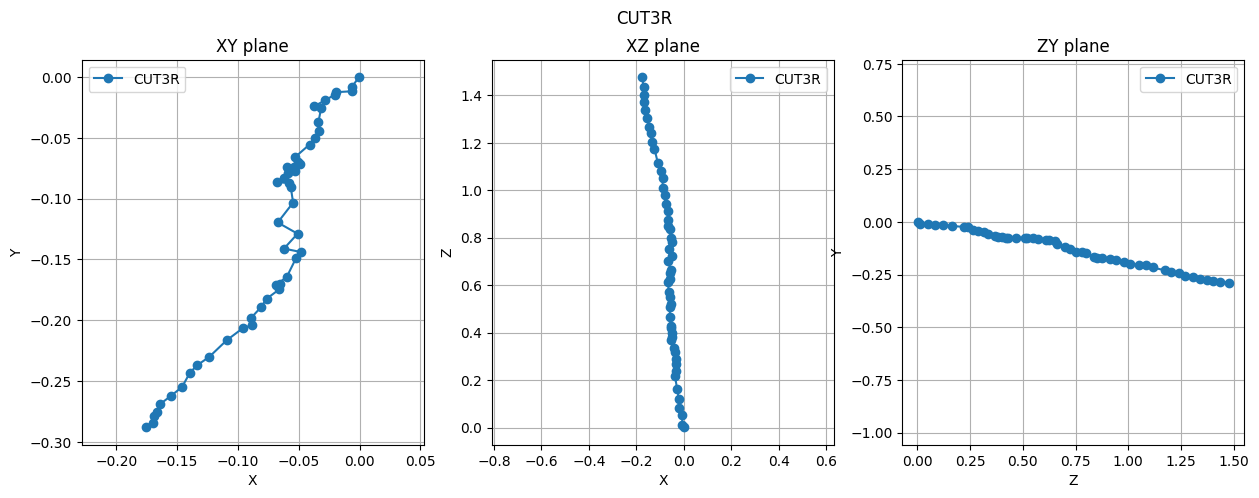

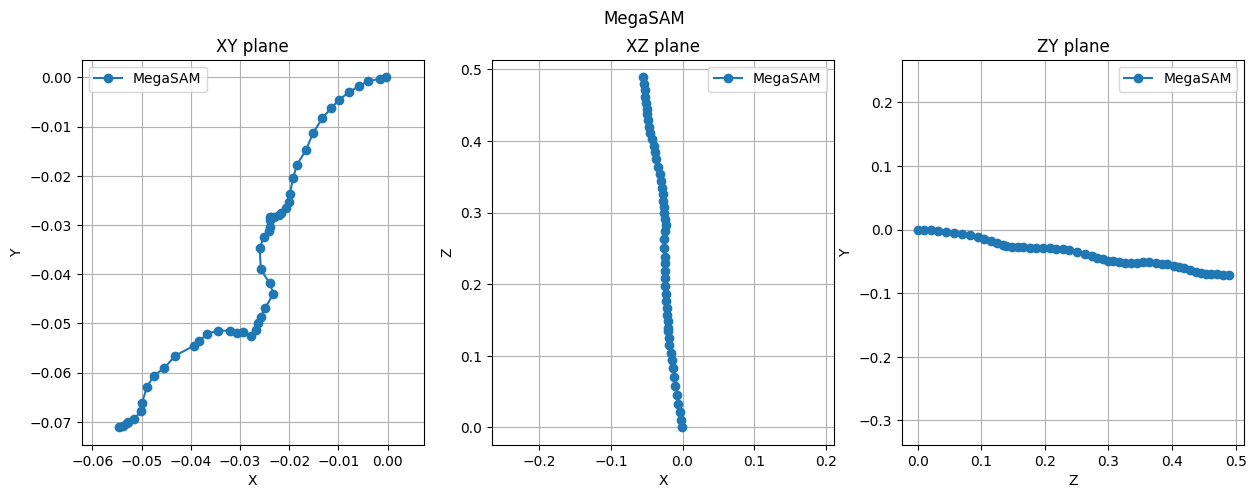

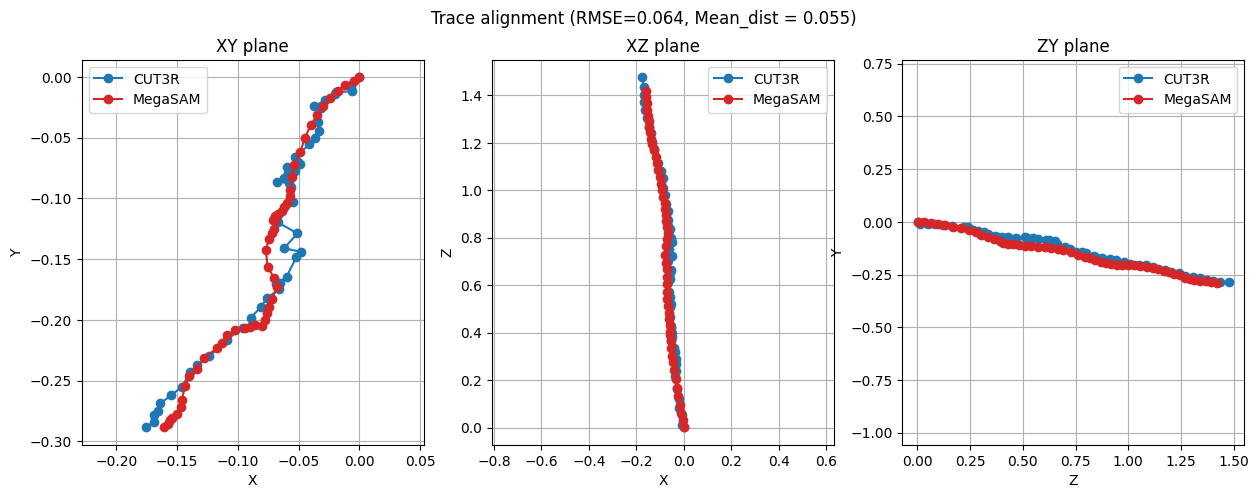

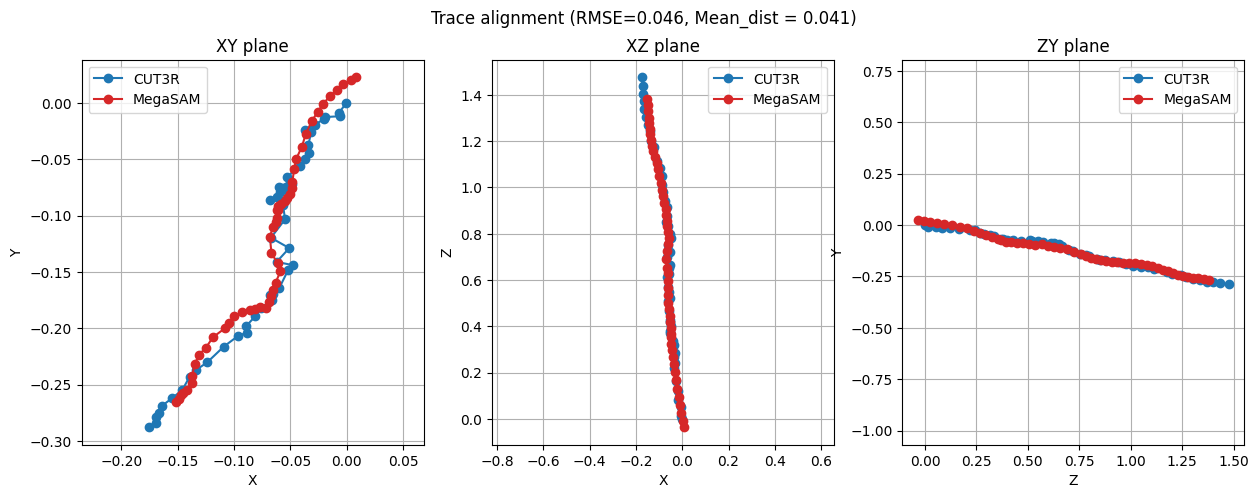

In [24]:
#CUT3R vs MegaSam
import importlib, sys
sys.path.insert(0, str(project_root / "src"))


print(case_dir)

A, dict = load_cut3r_trace_v2(case_dir / "035_CUT3R_output" / "21" / "camera")
#Data/01_walk/035_CUT3R_output/21/camera

B = load_megasam_trace(case_dir / "036_MEGASAM_output" / f"{case_name}_sgd_cvd_hr_01.npz")

assert A.shape == B.shape, f"Mismatched trace lengths: A={A.shape}, B={B.shape}"

R, s, t, B_aligned, rmse = umeyama_align(A, B, "CUT3R","MegaSAM", out_path =out_dir/"Initial_050_C_M.png" , anchor_index=0)
print("RMSE after alignment:", rmse)

# centroid-mode companion -- see notebook discussion: anchor_index=0 forces zero
# error at frame 0 and concentrates any R/s mismatch at the far end of the trace;
# centroid mode spreads it instead, so comparing the two shows whether divergence
# seen in the anchored chart is real or just where the anchor dumped the residual.
R_c, s_c, t_c, B_aligned_c, rmse_c = umeyama_align(A, B, "CUT3R","MegaSAM", out_path =out_dir/"Initial_050_C_M_centroid.png" , anchor_index=None)
print("RMSE (centroid):", rmse_c)

[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 3.82301336e-02 -4.80124921e-02 -1.53367109e-02]
 [ 1.36990250e-01 -1.10333484e-01 -4.63474960e-03]
 [ 2.14553643e-01 -1.71495948e-01 -9.92346019e-03]
 [ 2.83262818e-01 -2.35671629e-01 -7.10288942e-03]
 [ 3.52868377e-01 -2.91952914e-01  1.20474010e-02]
 [ 4.03454684e-01 -3.31364570e-01  2.76961171e-02]
 [ 4.55568067e-01 -3.89500769e-01  3.15285238e-02]
 [ 5.30958056e-01 -4.48624497e-01  9.73936026e-02]
 [ 5.87877797e-01 -4.90808227e-01  1.72137578e-01]
 [ 6.67486065e-01 -5.34132418e-01  2.03809351e-01]
 [ 6.78698484e-01 -5.90996299e-01  2.53643379e-01]
 [ 7.04521851e-01 -6.12724849e-01  3.40297994e-01]
 [ 7.12495270e-01 -6.95385332e-01  3.52232604e-01]
 [ 7.51254603e-01 -7.51847825e-01  3.60283920e-01]
 [ 7.92708923e-01 -8.03068701e-01  3.70869239e-01]
 [ 8.06516211e-01 -8.88389976e-01  3.39771726e-01]
 [ 8.49339785e-01 -9.55987547e-01  3.34162294e-01]
 [ 8.84071241e-01 -1.02161540e+00  3.22649311e-01]
 [ 9.06981856e-01 -1.08378503e+

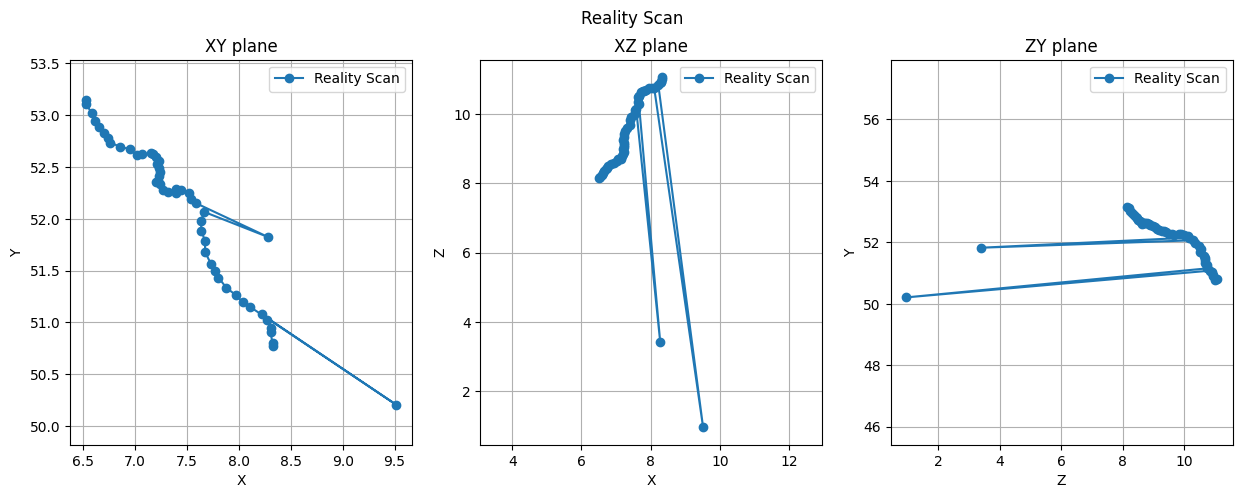

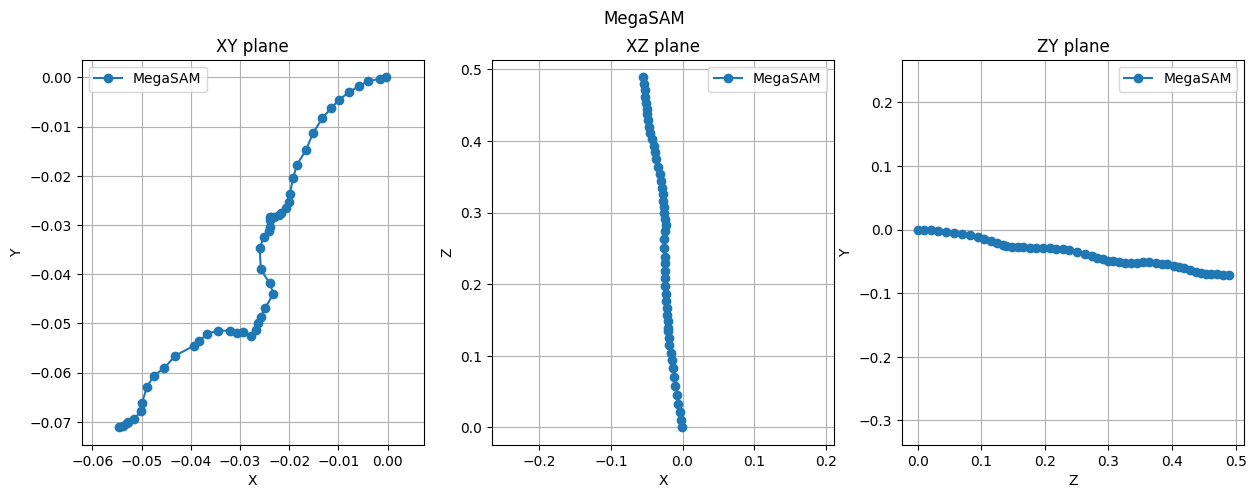

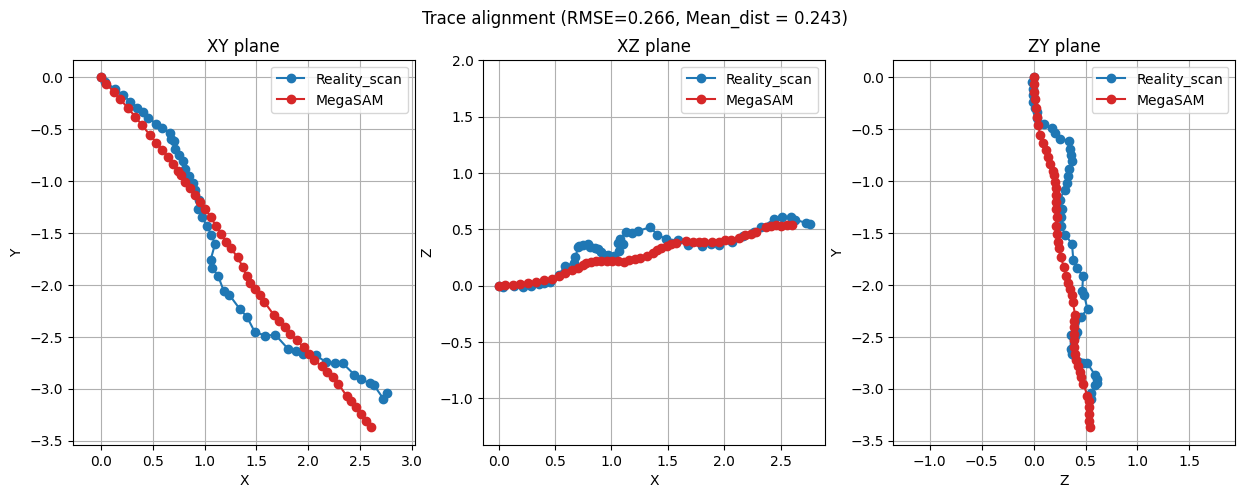

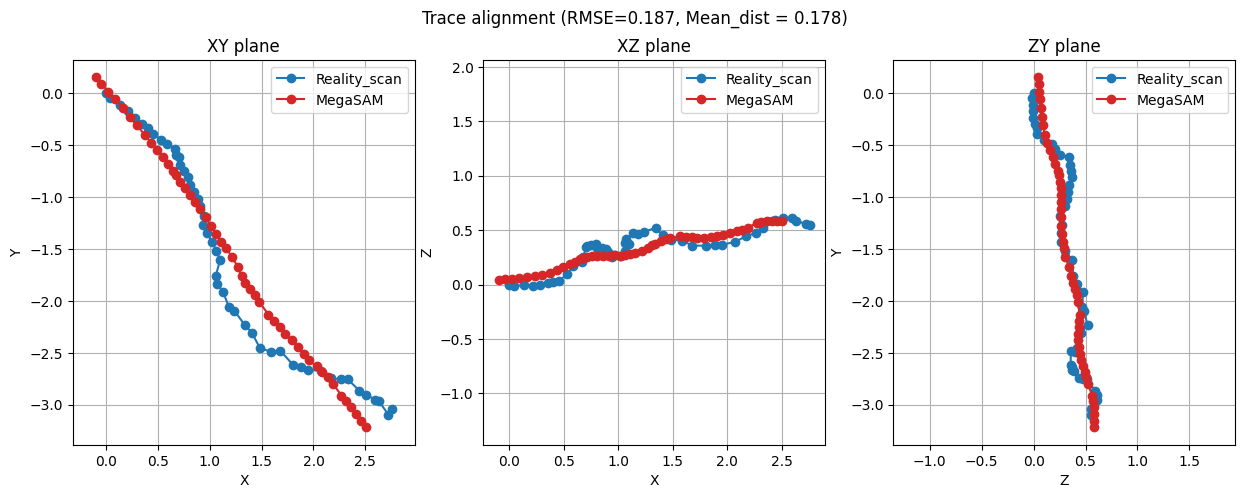

In [25]:
#COMPARE CAMERA SOLVES RS vs MEGASCAN
import sys
sys.path.insert(0, str(project_root / "src"))


Reality_scan, RS_dict = load_reality_scan_trace(case_dir / "030_Registrations"/"Registration_reality_scan" /"01_walk_initial_50_05b.csv")
B = load_megasam_trace(case_dir / "036_MEGASAM_output" / f"{case_name}_sgd_cvd_hr_01.npz")
print(Reality_scan)
assert A.shape == B.shape, f"Mismatched trace lengths: A={A.shape}, B={B.shape}"

R, s, t, B_aligned, rmse = umeyama_align(Reality_scan, B, "Reality_scan" , "MegaSAM" ,  out_path =out_dir/"Initial_050_RS_M.png" ,anchor_index=0, skip_indices=(31,44))
print("RMSE after alignment:", rmse)

R_c, s_c, t_c, B_aligned_c, rmse_c = umeyama_align(Reality_scan, B, "Reality_scan" , "MegaSAM" ,  out_path =out_dir/"Initial_050_RS_M_centroid.png" ,anchor_index=None, skip_indices=(31,44))
print("RMSE (centroid):", rmse_c)

A)
A,B 51 51
RMSE after alignment: 0.19963775914400655
A)
A,B 51 51
RMSE (centroid): 0.19353129229420415


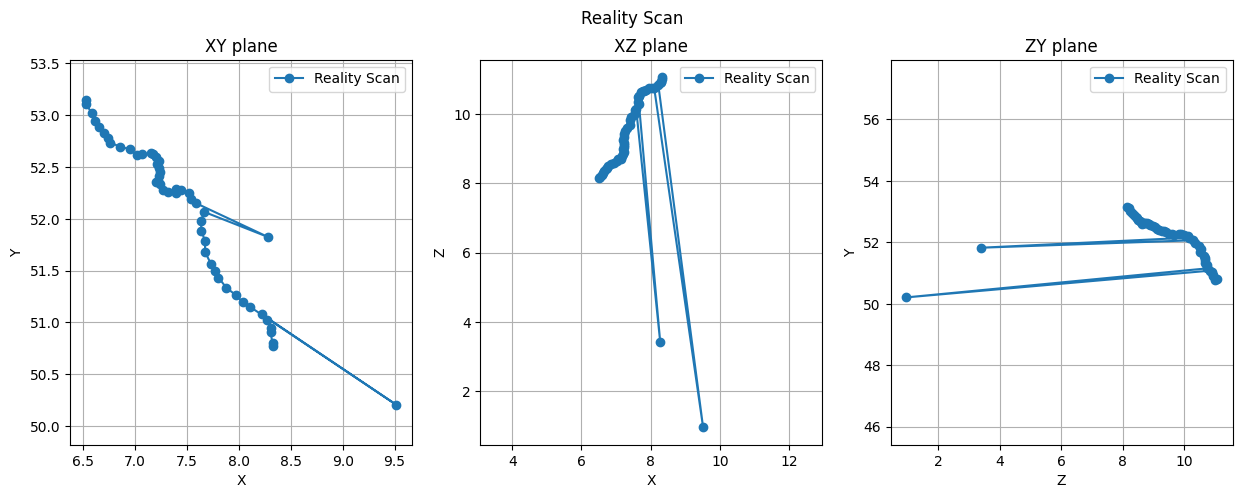

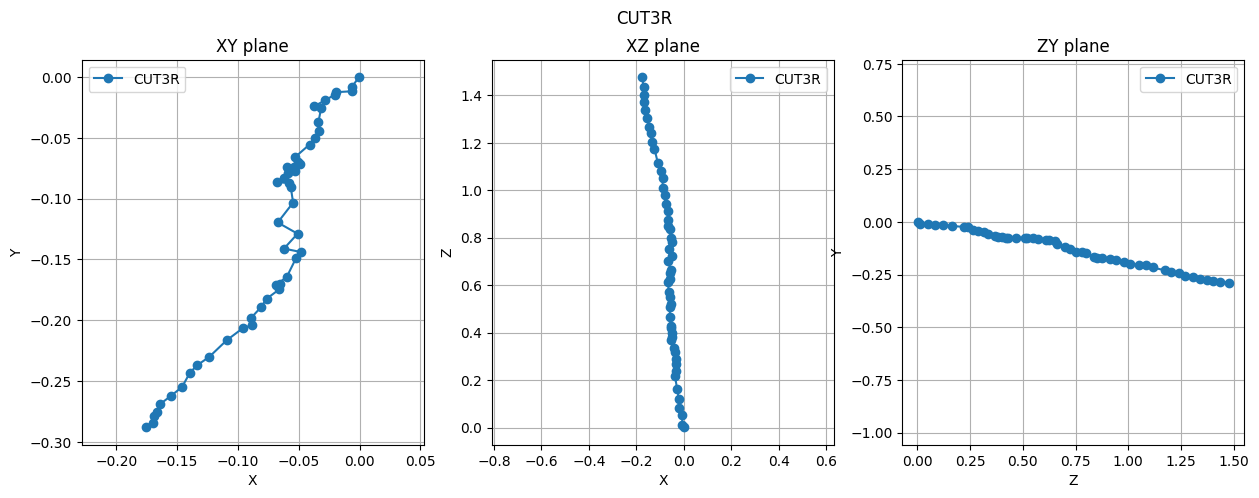

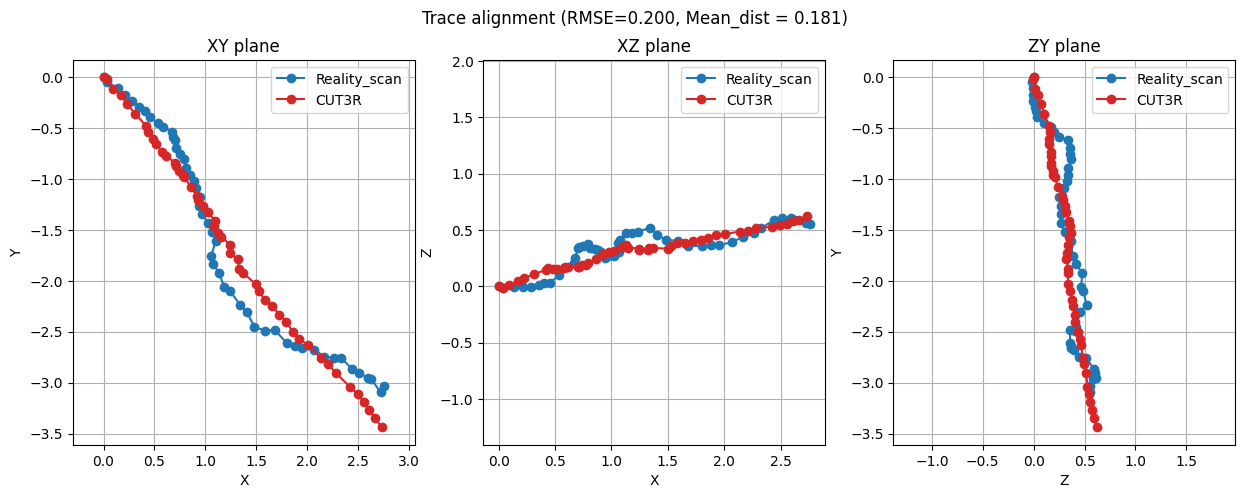

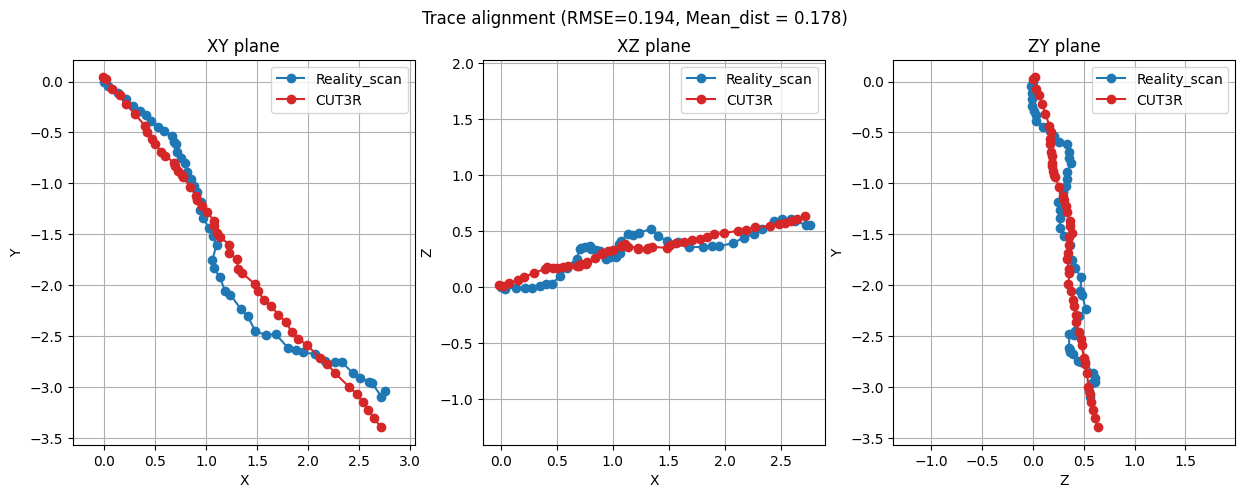

In [26]:
#COMPARE CAMERA SOLVES RS vs CUT3R
import sys
sys.path.insert(0, str(project_root / "src"))


Reality_scan, dict = load_reality_scan_trace(case_dir / "030_Registrations"/"Registration_reality_scan" /"01_walk_initial_50_05b.csv")
C = load_cut3r_trace(case_dir / "035_CUT3R_output" / "21" / "camera")

assert A.shape == B.shape, f"Mismatched trace lengths: A={A.shape}, B={B.shape}"

R, s, t, B_aligned, rmse = umeyama_align(Reality_scan, C, "Reality_scan" , "CUT3R" , out_path =out_dir/"Initial_050_RS_C.png"  , anchor_index=0, skip_indices=(31,44))
print("RMSE after alignment:", rmse)

R_c, s_c, t_c, B_aligned_c, rmse_c = umeyama_align(Reality_scan, C, "Reality_scan" , "CUT3R" , out_path =out_dir/"Initial_050_RS_C_centroid.png"  , anchor_index=None, skip_indices=(31,44))
print("RMSE (centroid):", rmse_c)

22/06 - moved onto FULL RES for rc and it works much better, so now for the comparisons

A)
A,B 50 50
RMSE after alignment: 4280.062543844494
A)
A,B 50 50
RMSE (centroid): 4000.8896845678432


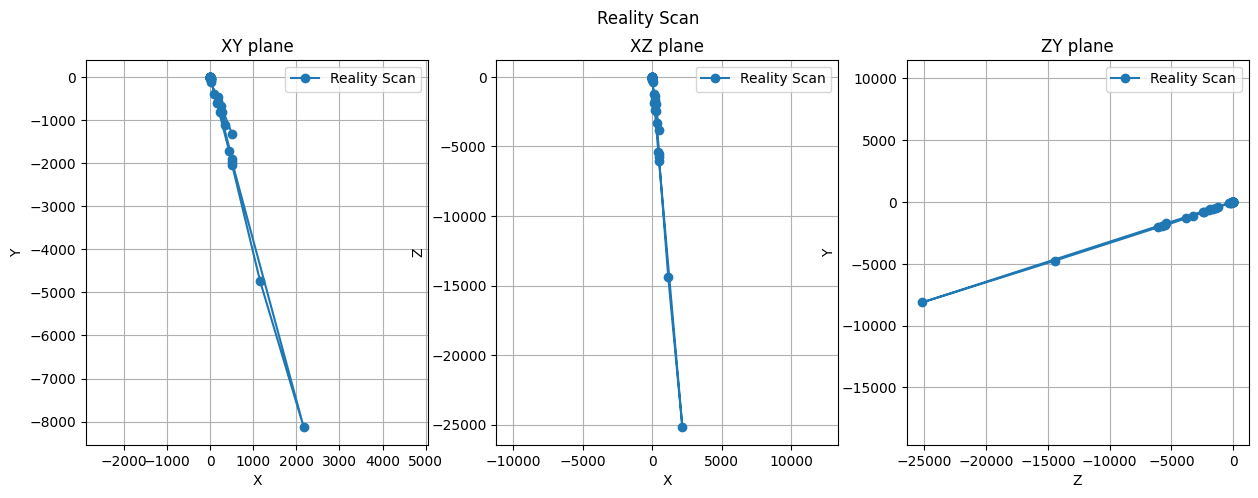

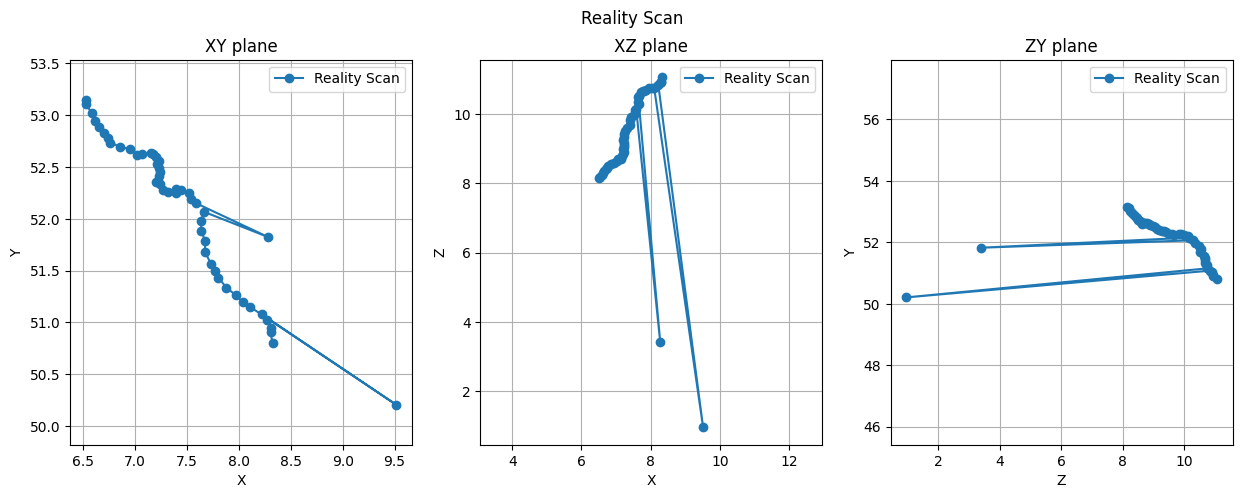

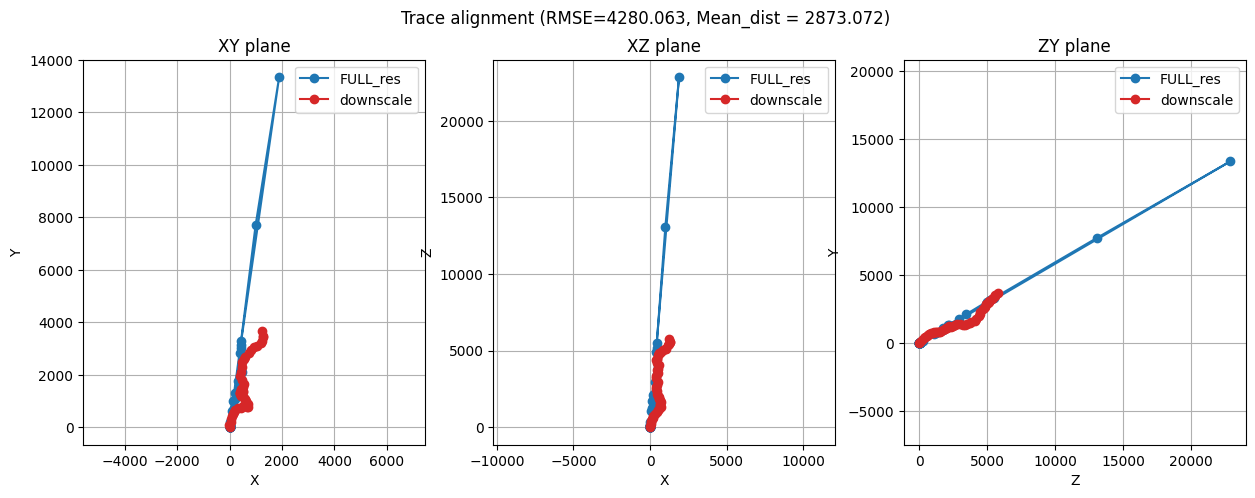

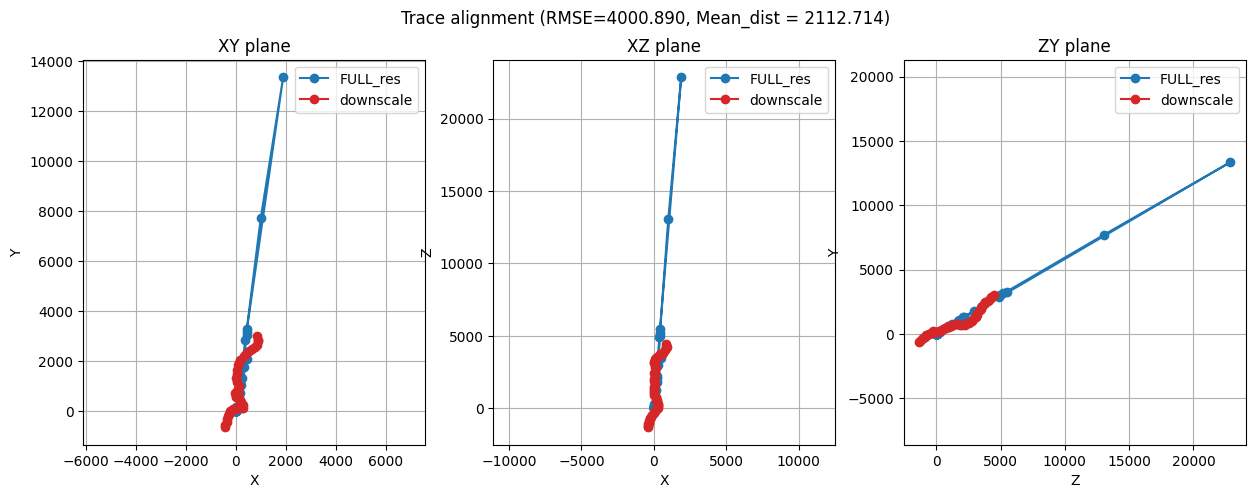

In [34]:
#RCfull vs RC 512

RS_init,dict = load_reality_scan_trace(case_dir / "030_Registrations"/"Registration_reality_scan" /"01_walk_initial_50_FULL.csv")
B,dict = load_reality_scan_trace(case_dir / "030_Registrations"/"Registration_reality_scan" /"01_walk_initial_50_05e.csv")

assert A.shape == B.shape, f"Mismatched trace lengths: A={A.shape}, B={B.shape}"

R, s, t, B_aligned, rmse = umeyama_align(RS_init, B, "FULL_res","downscale", out_path =out_dir/"Initial_050_RC_RC.png" , anchor_index=0,skip_indices=(31,44))
print("RMSE after alignment:", rmse)

R_c, s_c, t_c, B_aligned_c, rmse_c = umeyama_align(RS_init, B, "FULL_res","downscale", out_path =out_dir/"Initial_050_RC_RC_centroid.png" , anchor_index=None,skip_indices=(31,44))
print("RMSE (centroid):", rmse_c)

OK, after explorintg RC, 1 frame every 25 fames is working well - about 1s interval there.


50 FRAME INTERVALS:  01_walk_sparse_50_02_FULL_02

A)
A,B 50 50
RMSE after alignment: 1.046060660216002


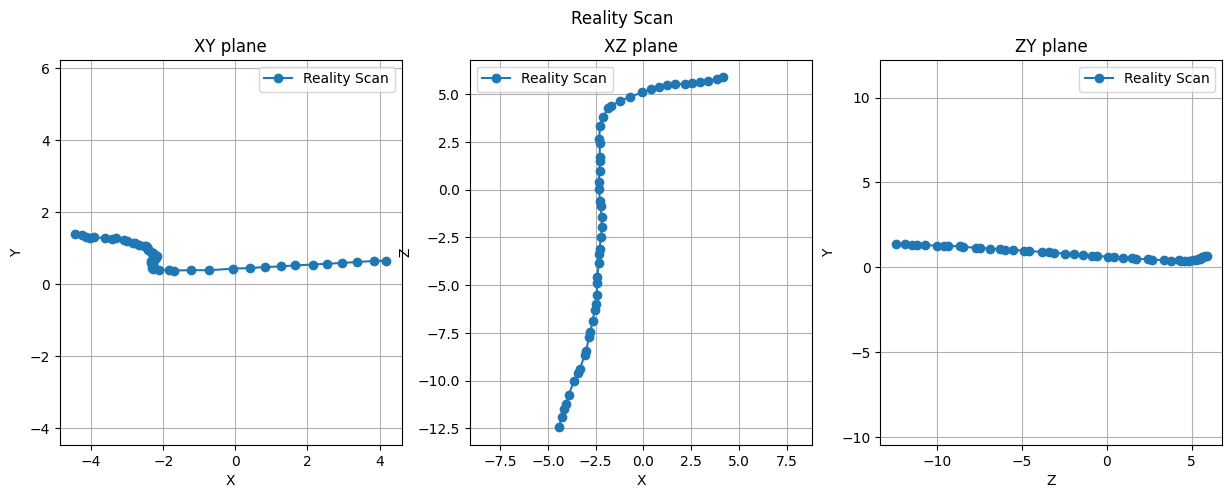

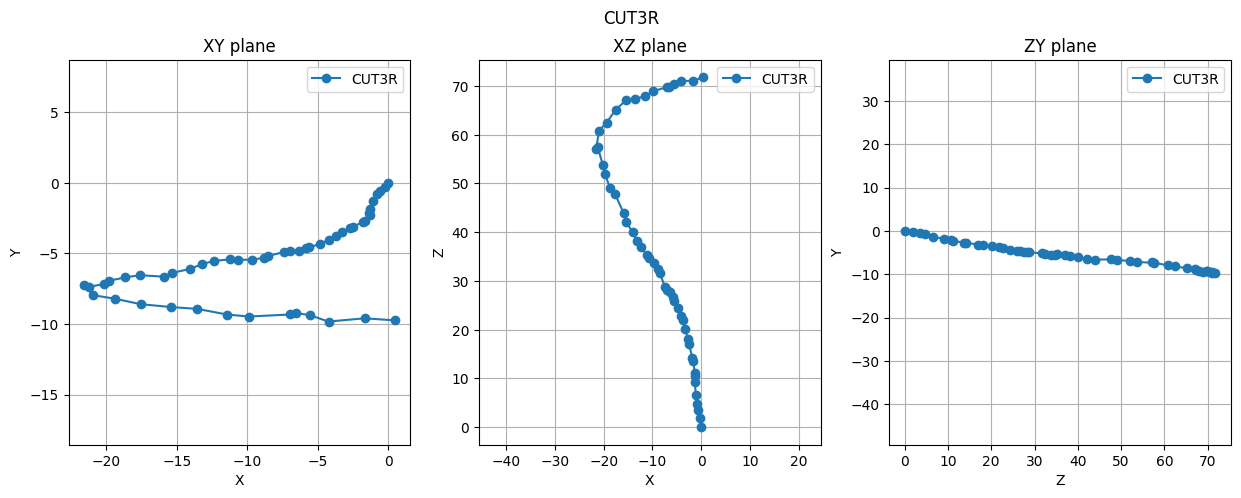

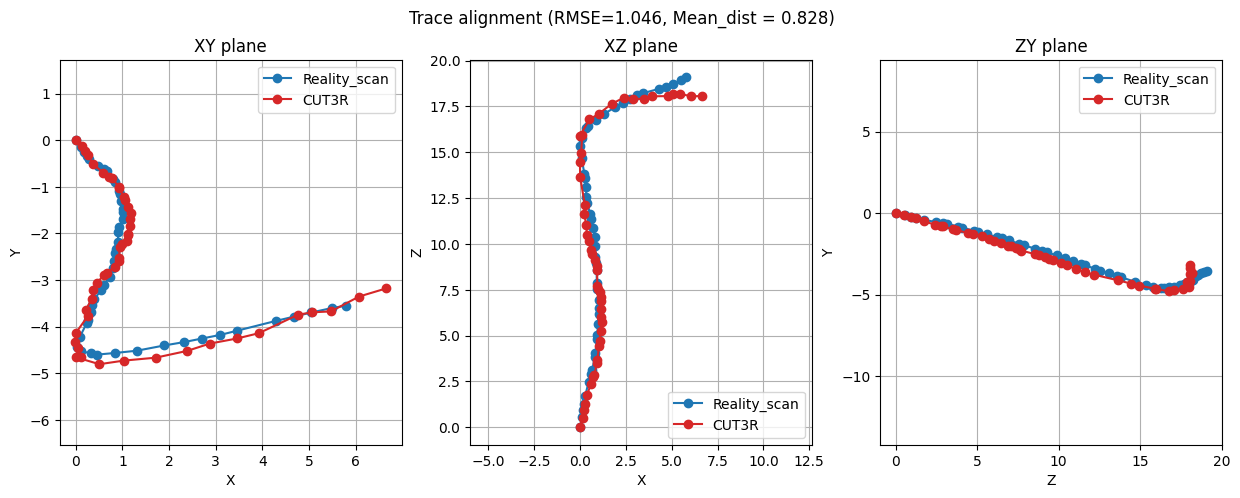

In [ ]:
#COMPARE CAMERA SOLVES RS vs CUT3R

RS, RS_dict = load_reality_scan_trace(case_dir / "030_Registrations"/"Registration_reality_scan" /"01_walk_sparse_50_02_full_02" /"01_walk_sparse_50_02_FULL_02.csv")
B = load_cut3r_trace(case_dir / "035_CUT3R_output" / "01_walk_sparse_50_02_full" / "camera")

assert A.shape == B.shape, f"Mismatched trace lengths: A={A.shape}, B={B.shape}"

R, s, t, B_aligned, rmse = umeyama_align(RS, B, "Reality_scan" , "CUT3R" , out_path =out_dir/"01_walk_sparse_50_02_RS_C.png"  , anchor_index=0, skip_indices=(31,44))
print("RMSE after alignment:", rmse)

A)
A,B 50 50
RMSE after alignment: 3.5220590291015768


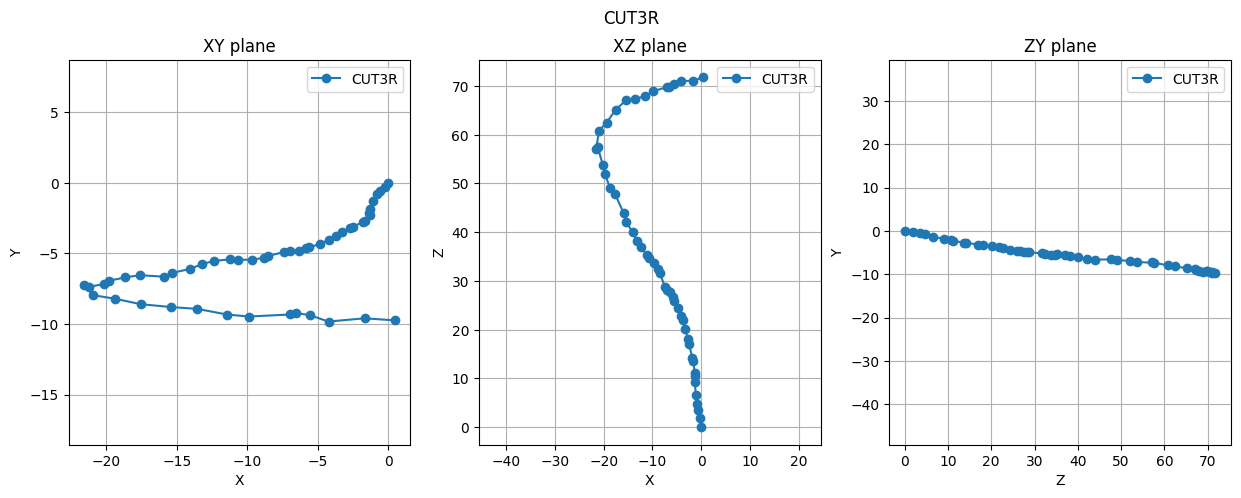

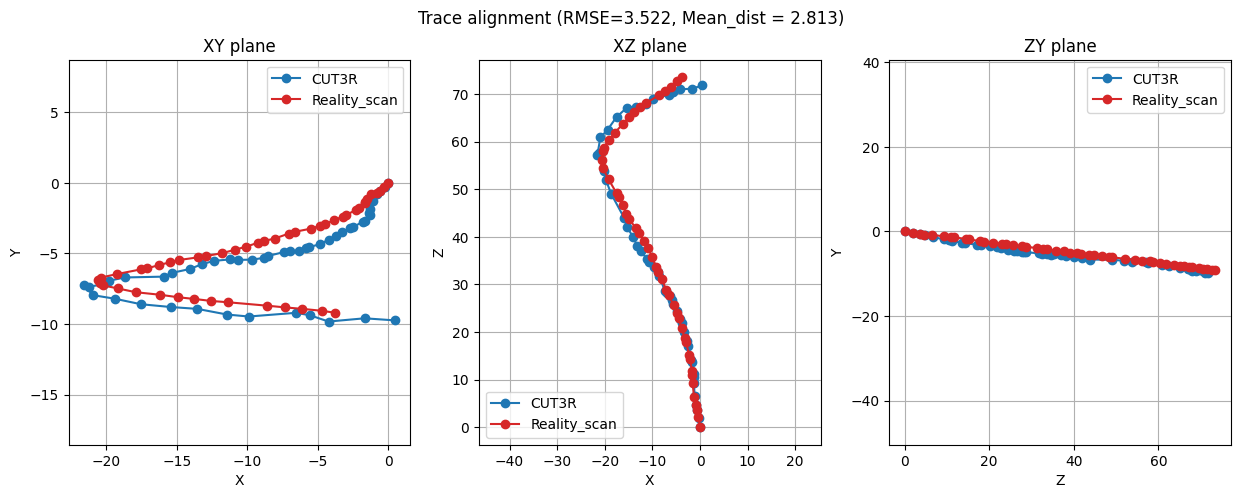

In [ ]:
#COMPARE CAMERA SOLVES CUT3R vs RS 

A = load_cut3r_trace(case_dir / "035_CUT3R_output" / "01_walk_sparse_50_02_full" / "camera")

assert A.shape == B.shape, f"Mismatched trace lengths: A={A.shape}, B={B.shape}"

R, s, t, B_aligned, rmse = umeyama_align(A, RS, "CUT3R", "Reality_scan"  , out_path =out_dir/"01_walk_sparse_50_02_RS_C.png"  , anchor_index=0, skip_indices=(31,44))
print("RMSE after alignment:", rmse)

A)
A,B 50 50
RMSE after alignment: 1.5177196329771339
A)
A,B 50 50
RMSE (centroid): 1.1530304030037655


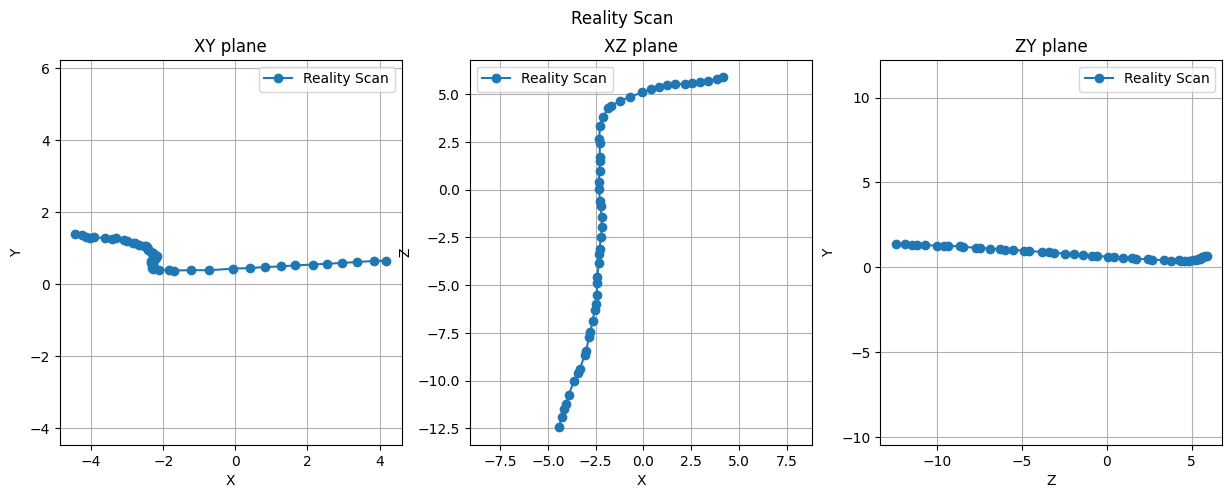

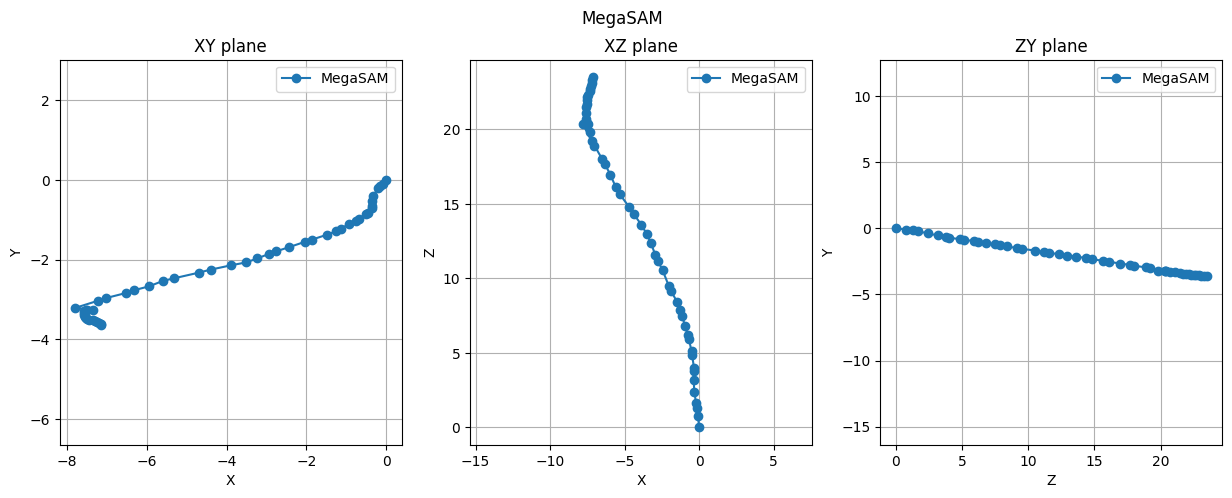

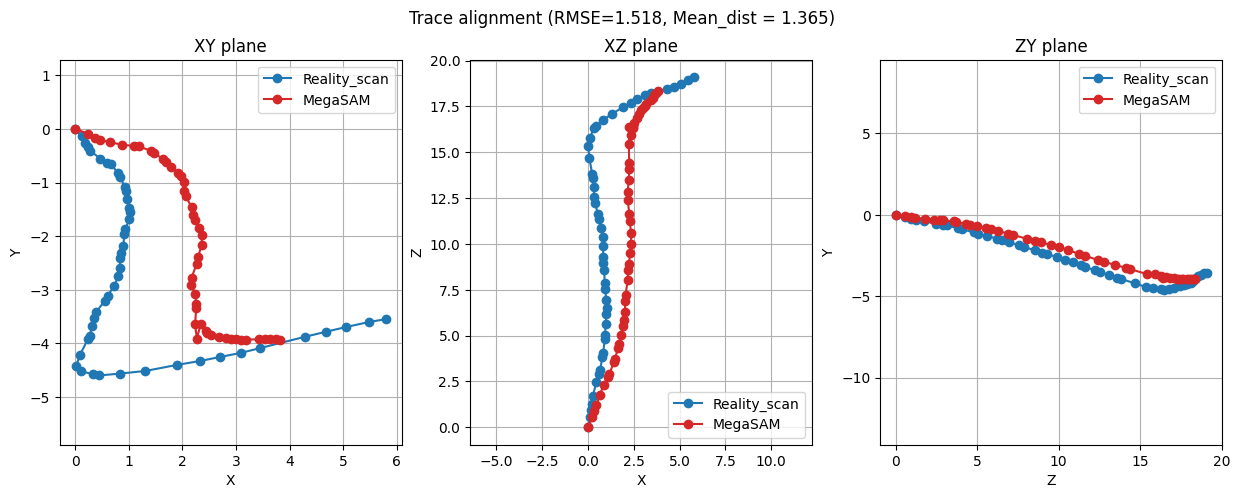

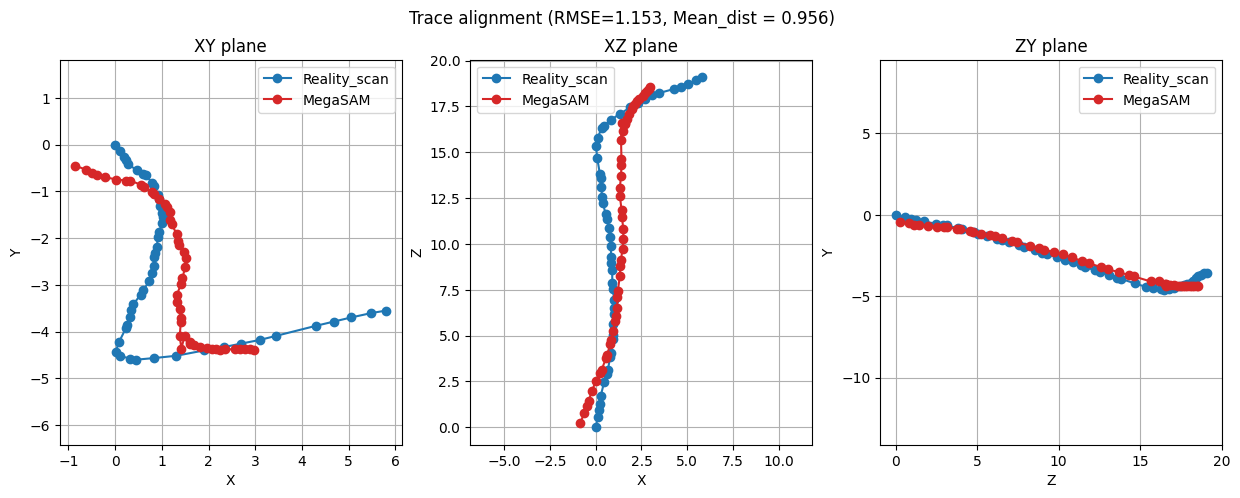

In [38]:
#COMPARE CAMERA SOLVES RS vs MEGASCAN


RS, dict = load_reality_scan_trace(case_dir / "030_Registrations"/"Registration_reality_scan" /"01_walk_sparse_50_02_full_02" /"01_walk_sparse_50_02_FULL_02.csv")
B = load_megasam_trace(case_dir / "036_MEGASAM_output" / "01_walk_sparse_50_02_full" / f"{case_name}_sgd_cvd_hr.npz")

assert RS.shape == B.shape, f"Mismatched trace lengths: A={A.shape}, B={B.shape}"

R, s, t, B_aligned, rmse = umeyama_align(RS, B, "Reality_scan" , "MegaSAM" ,  out_path =out_dir/"01_walk_sparse_50_02_full_RS_M.png" ,anchor_index=0, skip_indices=(31,44))
print("RMSE after alignment:", rmse)

R_c, s_c, t_c, B_aligned_c, rmse_c = umeyama_align(RS, B, "Reality_scan" , "MegaSAM" ,  out_path =out_dir/"01_walk_sparse_50_02_full_RS_M_centroid.png" ,anchor_index=None, skip_indices=(31,44))
print("RMSE (centroid):", rmse_c)

{0: array([-8.8044675e-05, -7.8559271e-04,  2.1755523e-03], dtype=float32), 1: array([-0.21555652, -0.31602678,  1.9556043 ], dtype=float32), 2: array([-0.5577746, -0.5407596,  3.5632577], dtype=float32), 3: array([-0.78613186, -0.7759314 ,  4.7450104 ], dtype=float32), 4: array([-1.1218133, -1.3093321,  6.631251 ], dtype=float32), 5: array([-1.2854823, -1.8699661,  9.202408 ], dtype=float32), 6: array([-1.3640234, -2.1397917, 10.605414 ], dtype=float32), 7: array([-1.2999219, -2.251887 , 11.16647  ], dtype=float32), 8: array([-1.6686344, -2.6997046, 13.603968 ], dtype=float32), 9: array([-1.8172252, -2.7401395, 14.168367 ], dtype=float32), 10: array([-2.4875588, -3.142905 , 17.031015 ], dtype=float32), 11: array([-2.7517614, -3.22972  , 18.111282 ], dtype=float32), 12: array([-3.2565374, -3.4950907, 20.09551  ], dtype=float32), 13: array([-3.7148368, -3.7905815, 21.906263 ], dtype=float32), 14: array([-4.227147, -4.02184 , 22.805548], dtype=float32), 15: array([-4.8132133, -4.326014 ,

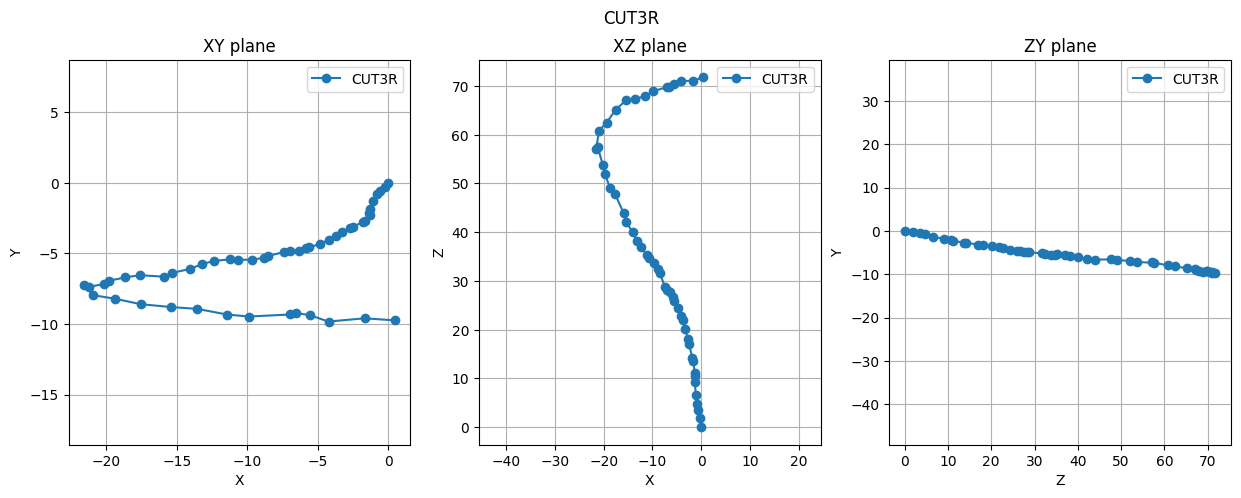

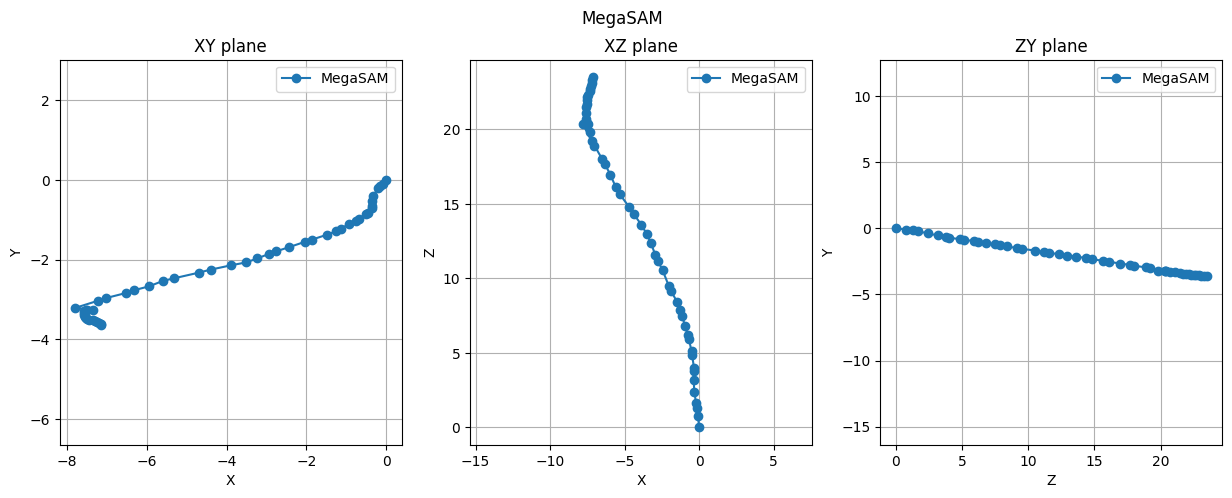

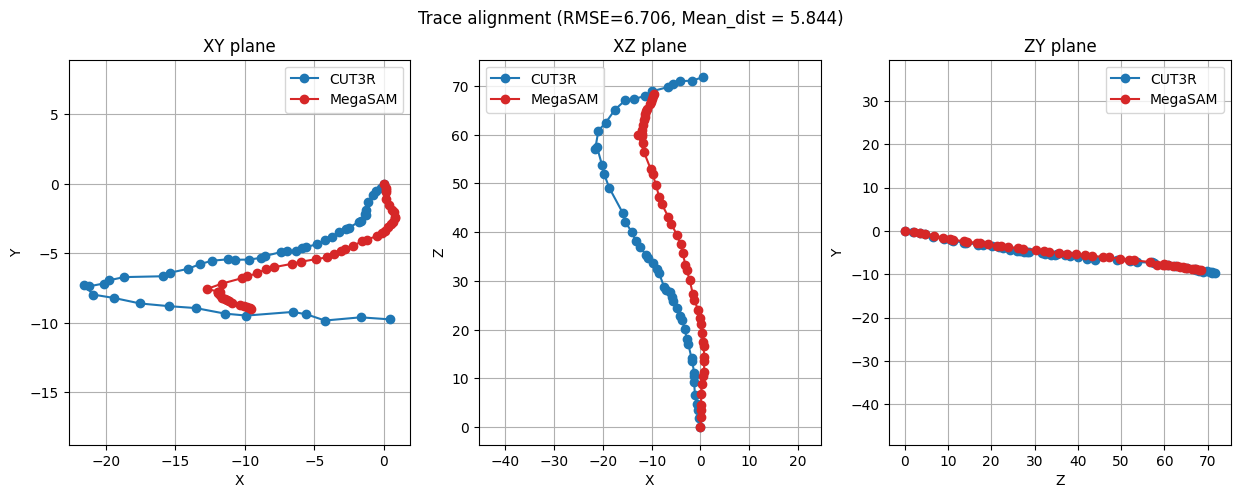

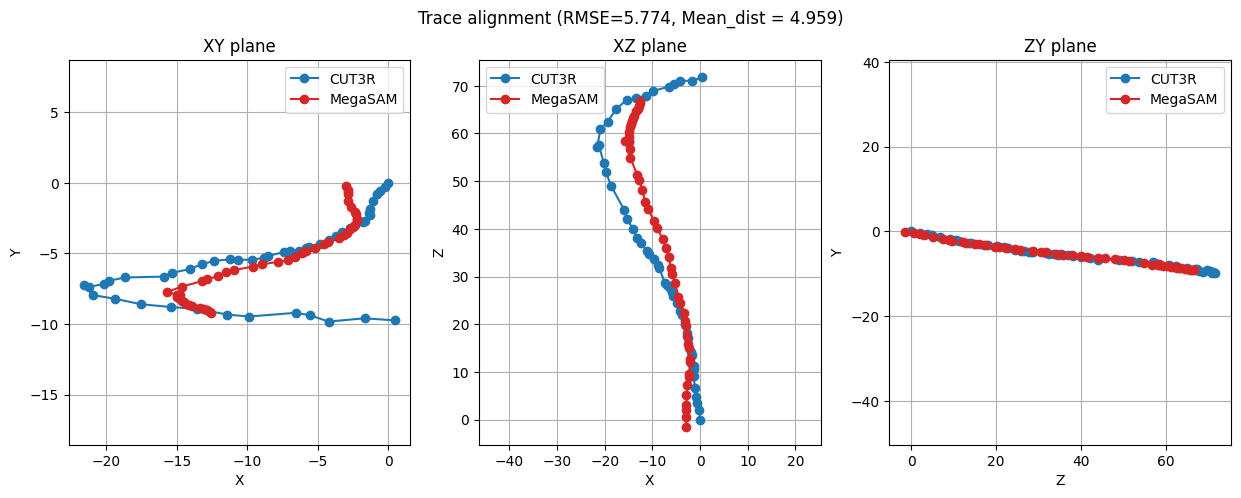

In [58]:
#COMPARE CAMERA SOLVES CUT3R vs MEGASCAN
frames_for_recon_dir = (case_dir / "020_frames_for_recon" / "01_walk_sparse_50_02_full")
CUT, CUT_dict = load_cut3r_trace_v2(case_dir / "035_CUT3R_output" / "01_walk_sparse_50_02_full" / "camera")
M, M_dict = load_megasam_trace(case_dir / "036_MEGASAM_output" / "01_walk_sparse_50_02_full" / f"{case_name}_sgd_cvd_hr.npz", frames_for_recon_dir)

assert CUT.shape == B.shape, f"Mismatched trace lengths: A={A.shape}, B={B.shape}"

R, s, t, B_aligned, rmse = umeyama_align(CUT, M, "CUT3R" , "MegaSAM" ,  out_path =out_dir/"01_walk_sparse_50_02_full_C_M.png" ,anchor_index=0, skip_indices=(31,44))
print("RMSE after alignment:", rmse)

R_c, s_c, t_c, B_aligned_c, rmse_c = umeyama_align(CUT, M, "CUT3R" , "MegaSAM" ,  out_path =out_dir/"01_walk_sparse_50_02_full_C_M_centroid.png" ,anchor_index=None, skip_indices=(31,44))
print("RMSE (centroid):", rmse_c)

A)
A,B 50 50
RMSE after alignment: 0.1383928201892225
A)
A,B 50 50
RMSE (centroid): 0.1287282429677885


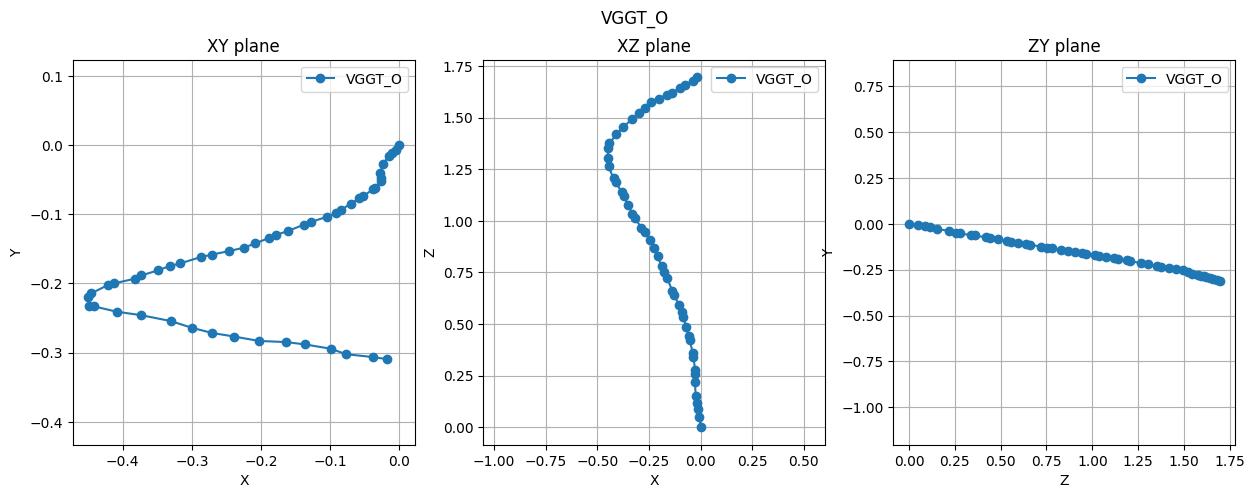

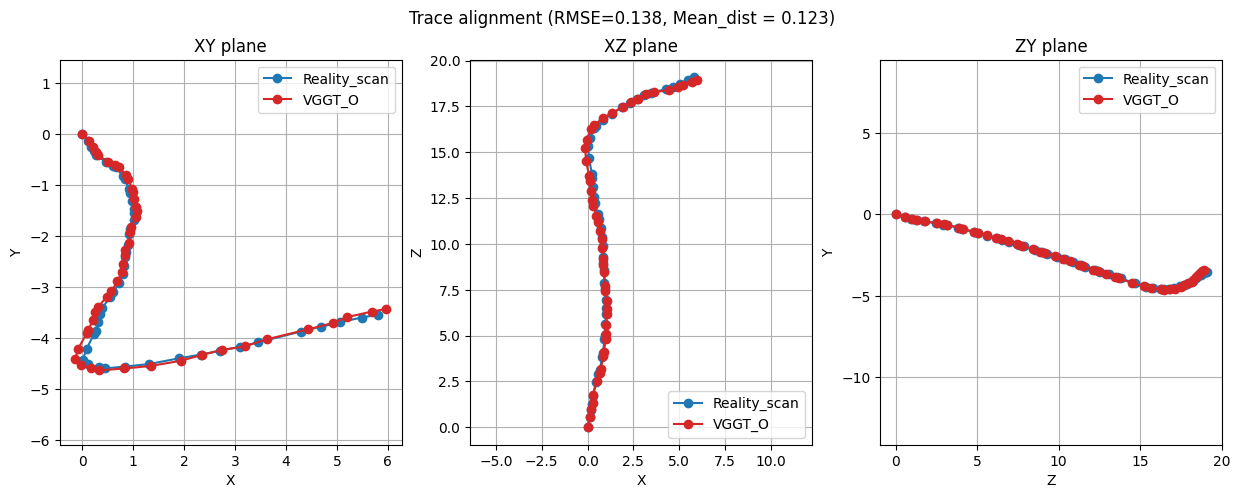

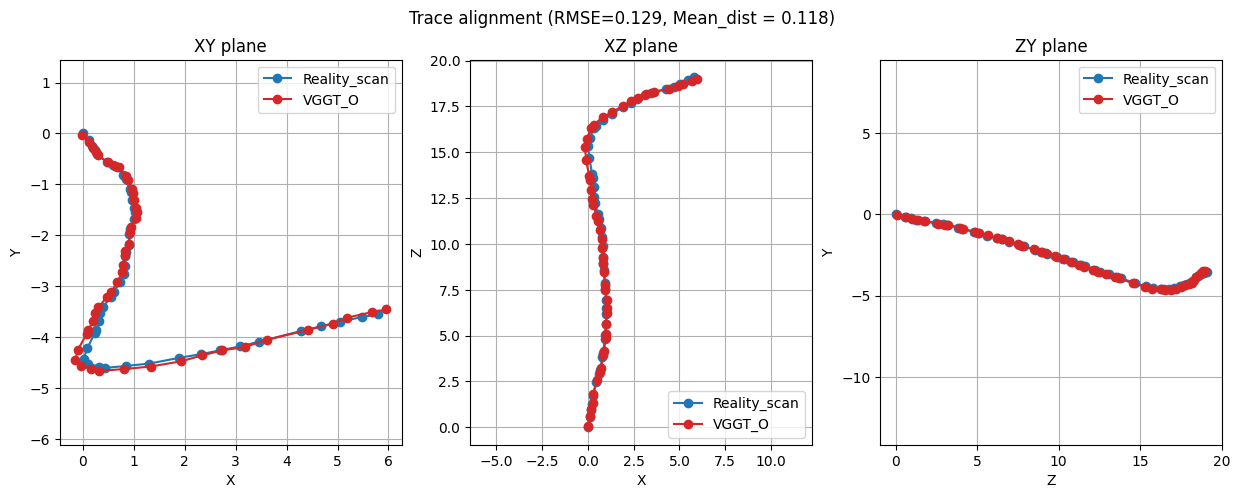

In [64]:
VGGTO,VGGTO_dict  = load_VGGT_O_trace((case_dir / "035_VGGT_O_output" / "01_walk_sparse_50_02_full" / "predictions.npz"), frames_dir = frames_for_recon_dir)
R, s, t, B_aligned, rmse = umeyama_align(RS,VGGTO , "Reality_scan" , "VGGT_O" ,  out_path =out_dir/"01_walk_sparse_50_02_full_RS_VGGTO.png" ,anchor_index=0, skip_indices=(31,44))
print("RMSE after alignment:", rmse)

R_c, s_c, t_c, B_aligned_c, rmse_c = umeyama_align(RS,VGGTO , "Reality_scan" , "VGGT_O" ,  out_path =out_dir/"01_walk_sparse_50_02_full_RS_VGGTO_centroid.png" ,anchor_index=None, skip_indices=(31,44))
print("RMSE (centroid):", rmse_c)

A)
A,B 50 50
RMSE after alignment (lingbot vs VGGT_O): 0.19677431702049317
A)
A,B 50 50
RMSE (centroid, lingbot vs VGGT_O): 0.05322768332304571
A)
A,B 50 50
RMSE after alignment (RS vs lingbot): 1.105537520114496
A)
A,B 50 50
RMSE (centroid, RS vs lingbot): 0.2820280482054968


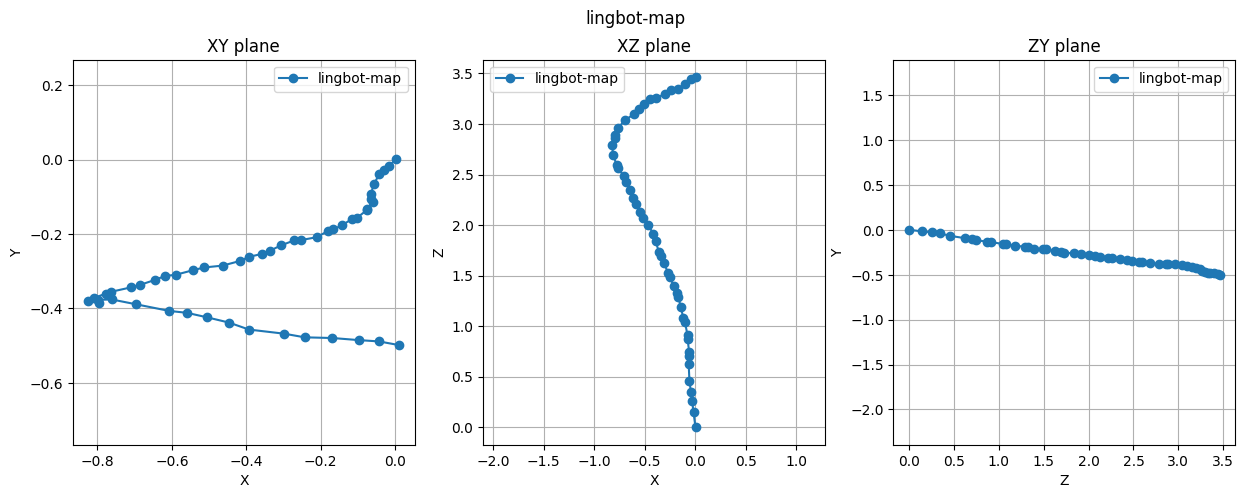

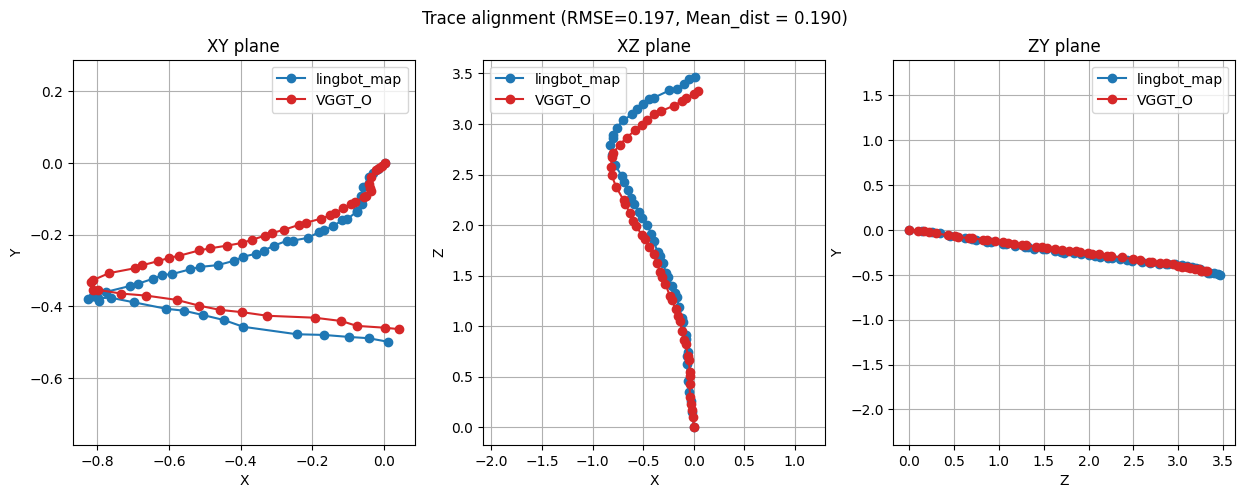

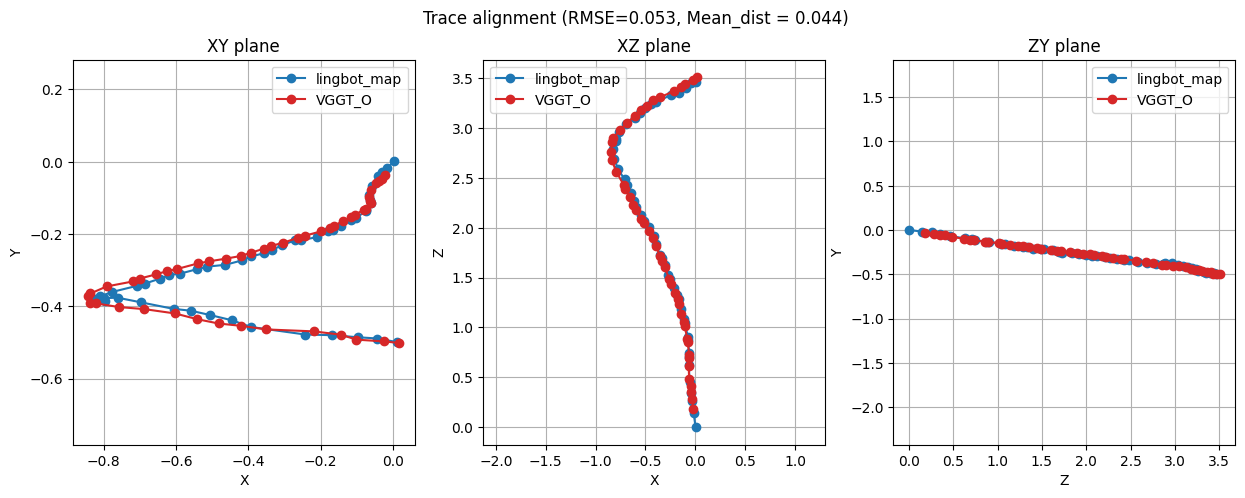

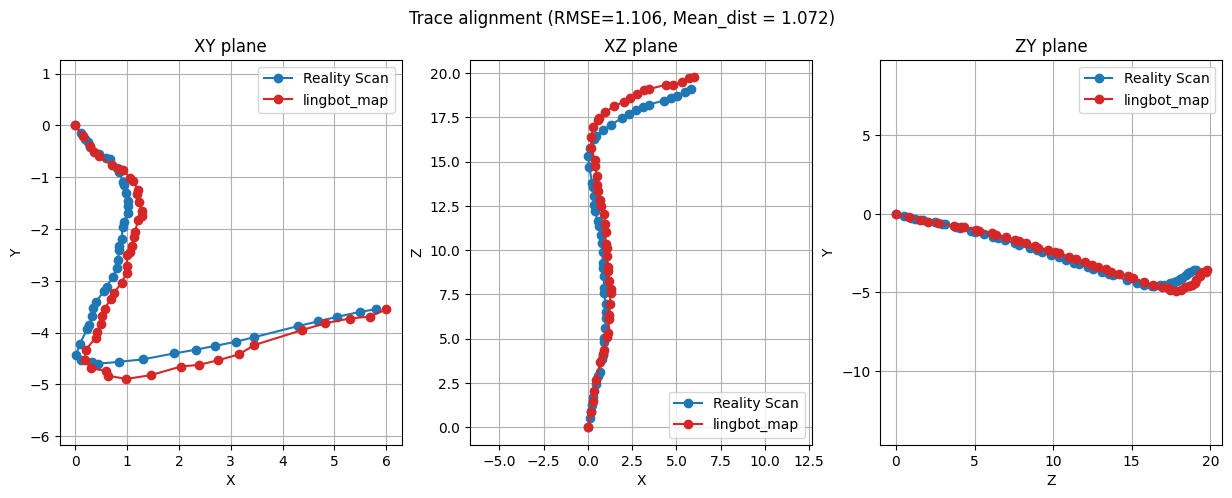

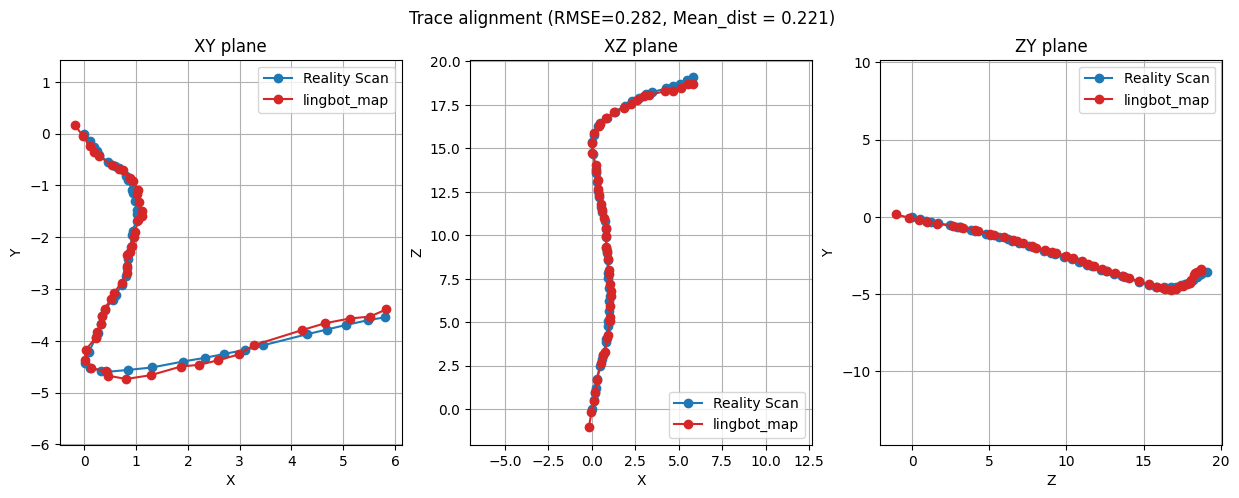

In [41]:
from F_post_recon_processing import load_lingbot_map_trace
lb, lb_dict = load_lingbot_map_trace(case_dir / "036_lingbot_map_output" / "01_walk_sparse_50_02_full")
R, s, t, B_aligned, rmse = umeyama_align(lb, VGGTO , "lingbot_map" , "VGGT_O" ,  out_path =out_dir/"01_walk_sparse_50_02_full_lingbot_VGGTO.png" ,anchor_index=0, skip_indices=(31,44))
print("RMSE after alignment (lingbot vs VGGT_O):", rmse)
R_c, s_c, t_c, B_aligned_c, rmse_c = umeyama_align(lb, VGGTO , "lingbot_map" , "VGGT_O" ,  out_path =out_dir/"01_walk_sparse_50_02_full_lingbot_VGGTO_centroid.png" ,anchor_index=None, skip_indices=(31,44))
print("RMSE (centroid, lingbot vs VGGT_O):", rmse_c)

R, s, t, B_aligned, rmse = umeyama_align(RS, lb,  "Reality Scan" , "lingbot_map" ,  out_path =out_dir/"01_walk_sparse_50_02_full_RS_lingbot.png" ,anchor_index=0, skip_indices=(31,44))
print("RMSE after alignment (RS vs lingbot):", rmse)
R_c, s_c, t_c, B_aligned_c, rmse_c = umeyama_align(RS, lb,  "Reality Scan" , "lingbot_map" ,  out_path =out_dir/"01_walk_sparse_50_02_full_RS_lingbot_centroid.png" ,anchor_index=None, skip_indices=(31,44))
print("RMSE (centroid, RS vs lingbot):", rmse_c)

BRING IN THE GPS SIGNALS AND REPEAT!

{0: array([0.00264047, 0.00064559, 0.00030363], dtype=float32), 1: array([-0.01712874, -0.01713507,  0.14650385], dtype=float32), 2: array([-0.03064946, -0.02719748,  0.26027167], dtype=float32), 3: array([-0.04248606, -0.03930483,  0.3476119 ], dtype=float32), 4: array([-0.05751422, -0.06684472,  0.45758873], dtype=float32), 5: array([-0.06524371, -0.09331784,  0.62878335], dtype=float32), 6: array([-0.06470177, -0.10572909,  0.7069923 ], dtype=float32), 7: array([-0.06068438, -0.11333582,  0.7455845 ], dtype=float32), 8: array([-0.07547872, -0.13360813,  0.8729207 ], dtype=float32), 9: array([-0.0760129, -0.1357459,  0.9077185], dtype=float32), 10: array([-0.10220963, -0.15646523,  1.0429027 ], dtype=float32), 11: array([-0.11723202, -0.16060178,  1.0811996 ], dtype=float32), 12: array([-0.14334393, -0.17688647,  1.1852498 ], dtype=float32), 13: array([-0.16621783, -0.18763684,  1.287276  ], dtype=float32), 14: array([-0.18043193, -0.1920369 ,  1.3288255 ], dtype=float32), 15: array(

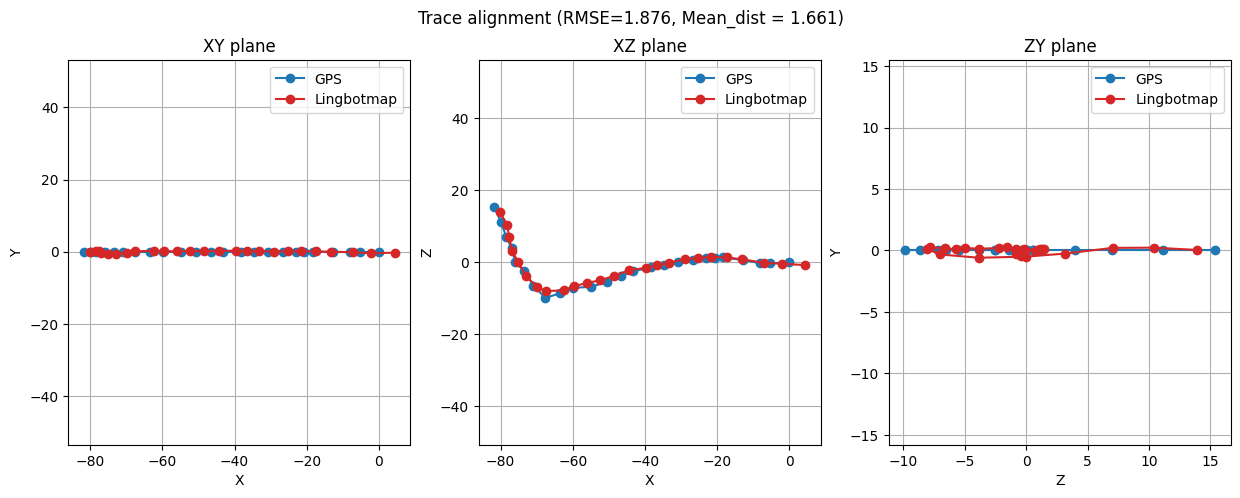

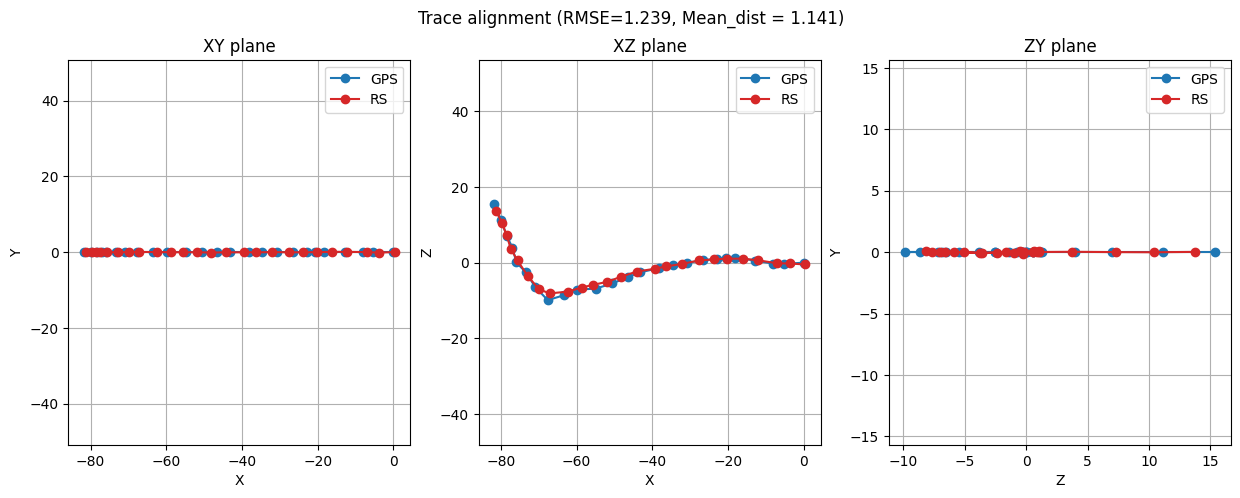

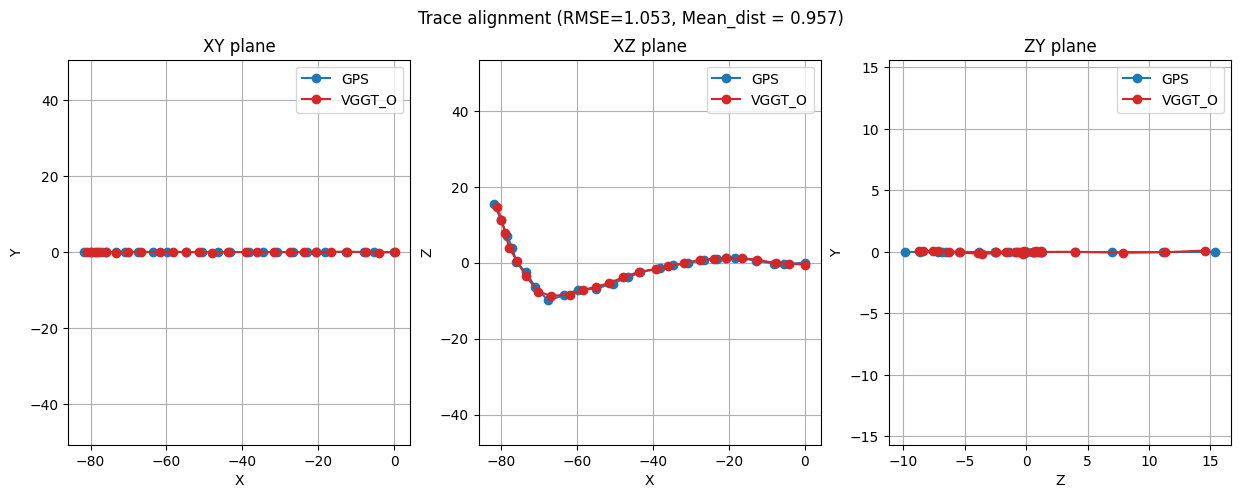

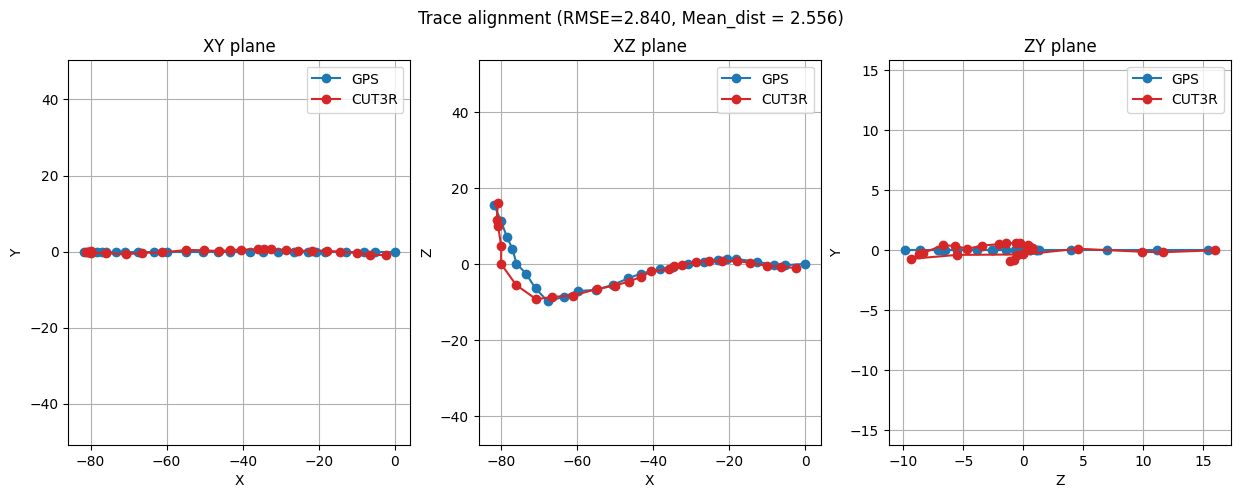

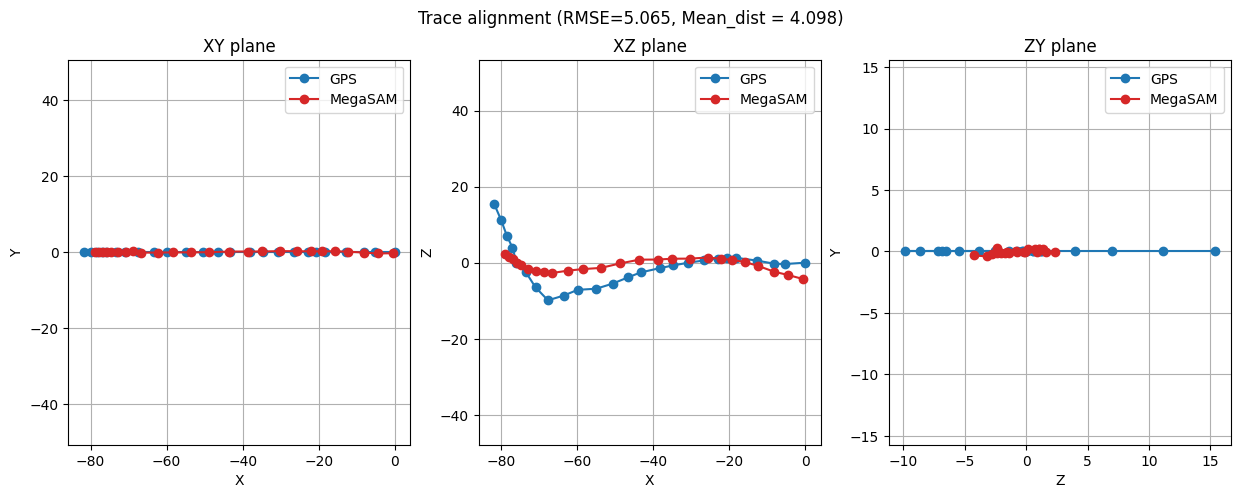

In [71]:
#convert CAMERA POSES from RS model-world-space (set to CAM0) into real-world-space 
#get lat lon positions
#get transforms to convert other things too
csv_path_GPS = case_dir     / "000_GPS_Data" / "GPS_tags.csv"
from Q_Metric_georeferencing import model_to_GPS_calibrated_locations
csv_path_pose = lb_dict
print(csv_path_pose)
lb_W_dict, cam_latlons, R_cw, s_cw, t_cw, lat_0, lon_0 = model_to_GPS_calibrated_locations (csv_path_GPS, lb_dict, Source = "Lingbotmap" )
RS_W_dict, cam_latlons, R_cw, s_cw, t_cw, lat_0, lon_0 = model_to_GPS_calibrated_locations (csv_path_GPS, RS_dict, Source = "RS" )
VGGT_O_W_dict, cam_latlons, R_cw, s_cw, t_cw, lat_0, lon_0 = model_to_GPS_calibrated_locations (csv_path_GPS, VGGTO_dict, Source = "VGGT_O" )
CUT_W_dict, cam_latlons, R_cw, s_cw, t_cw, lat_0, lon_0 = model_to_GPS_calibrated_locations (csv_path_GPS, CUT_dict, Source = "CUT3R" )
M_W_dict, cam_latlons, R_cw, s_cw, t_cw, lat_0, lon_0 = model_to_GPS_calibrated_locations (csv_path_GPS, M_dict, Source = "MegaSAM" )


In [119]:
pip install tabulate

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


A)
A,B 25 25
A)
A,B 25 25
A)
A,B 25 25


A)
A,B 25 25
A)
A,B 25 25
| technique    |   rmse |   mean_dist |   n_points |   trajectory_length |   spatial_extent |   rmse_cm_per_m |
|:-------------|-------:|------------:|-----------:|--------------------:|-----------------:|----------------:|
| VGGT_O       |  1.053 |       0.957 |         25 |               98.81 |           26.547 |           1.066 |
| Reality_Scan |  1.239 |       1.141 |         25 |               98.81 |           26.547 |           1.254 |
| lingbot_map  |  1.876 |       1.661 |         25 |               98.81 |           26.547 |           1.899 |
| CUT3R        |  2.84  |       2.556 |         25 |               98.81 |           26.547 |           2.874 |
| MegaSAM      |  5.065 |       4.098 |         25 |               98.81 |           26.547 |           5.126 |


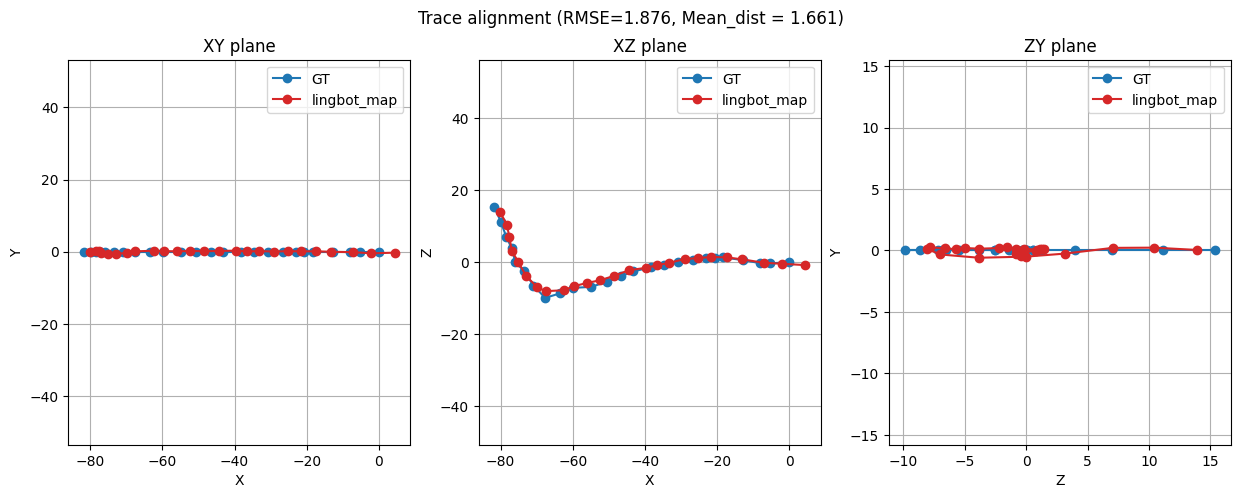

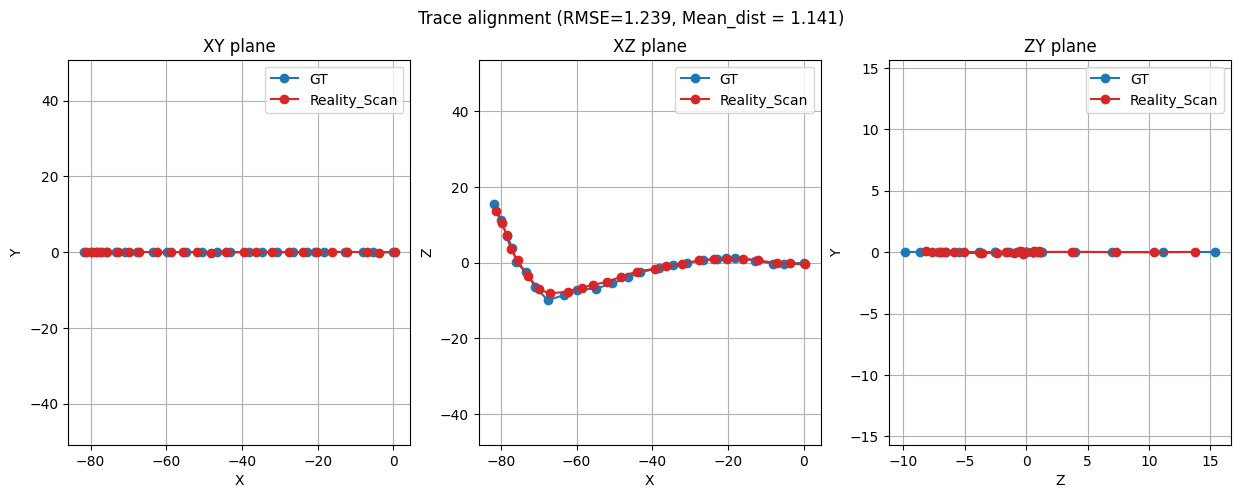

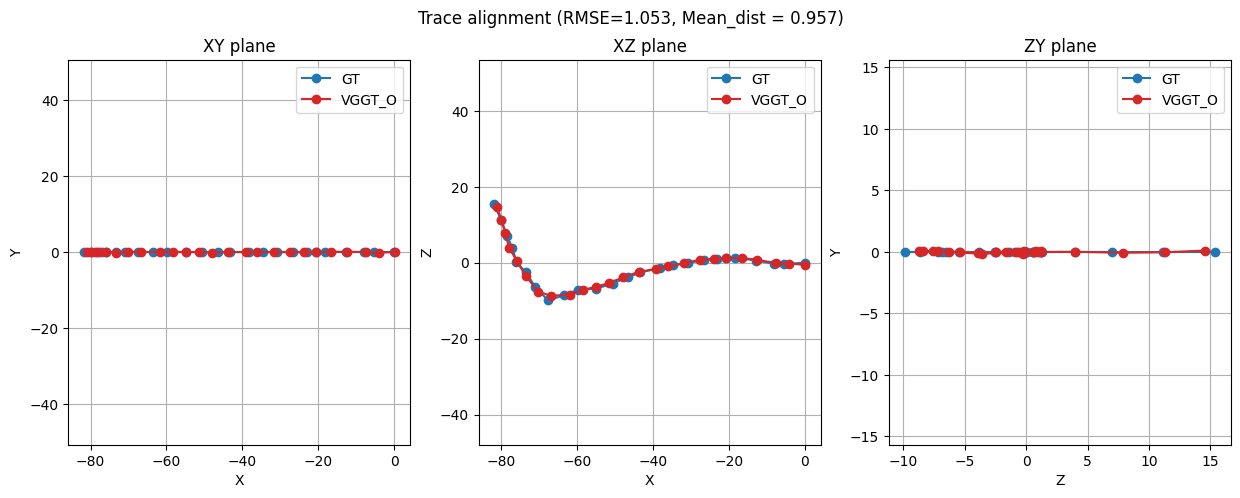

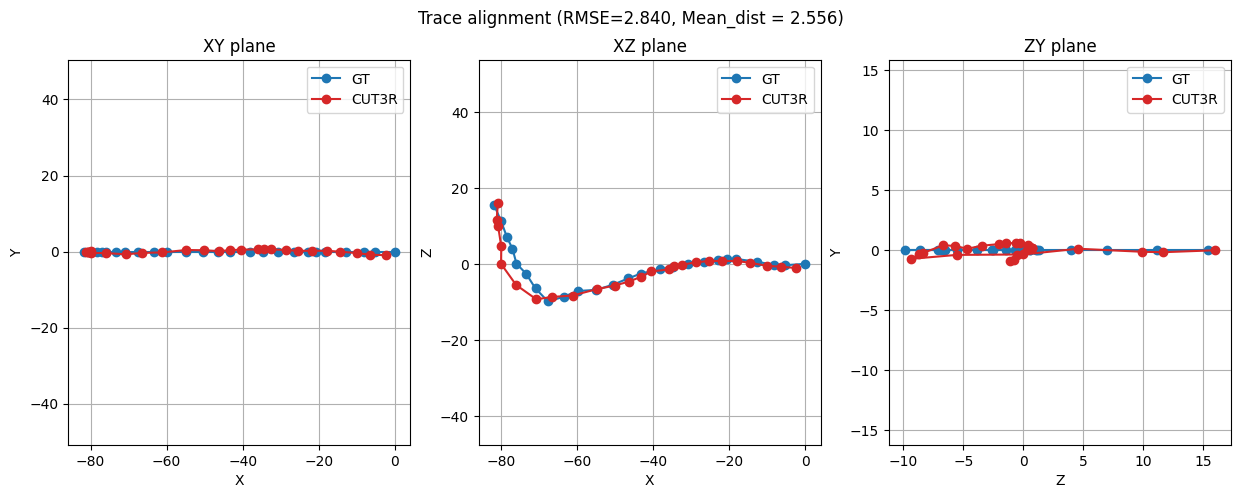

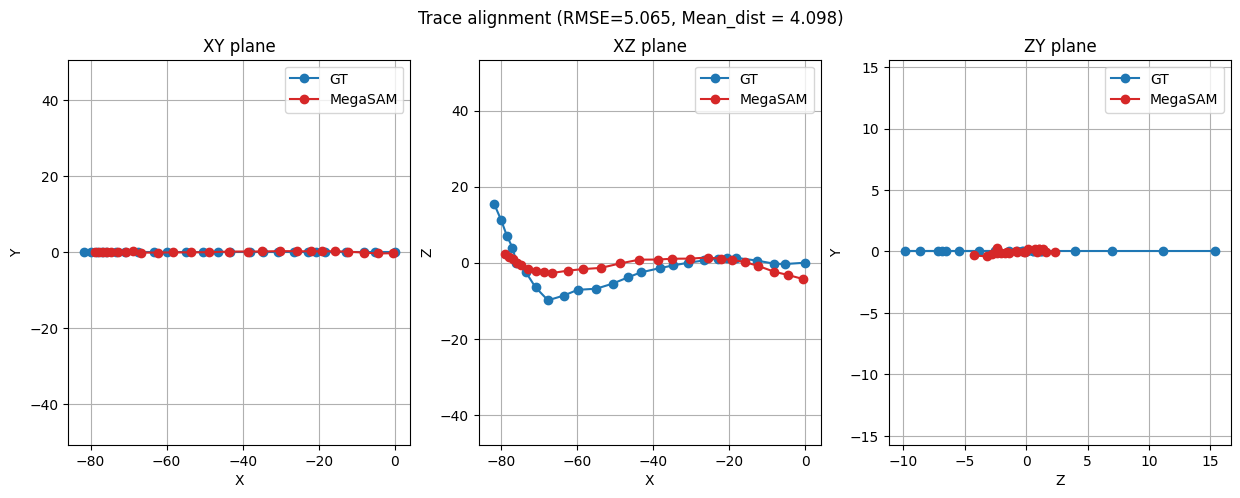

In [120]:
from G_transforms_alignments import umeyama_align
from Q_Metric_georeferencing import GPS_camerapose_matcher
from Q_GPS_processing import csv_to_GPS_dict
import numpy as np
import pandas as pd

GPS_dict = csv_to_GPS_dict(csv_path_GPS)


def trajectory_length(positions):
    return float(np.sum(np.linalg.norm(np.diff(positions, axis=0), axis=1)))


def spatial_extent(positions):
    centroid = positions.mean(axis=0)
    return float(np.sqrt(np.mean(np.sum((positions - centroid) ** 2, axis=1))))


def align_and_score(technique, world_pos_dict):
    GPS_locs, lat_0, lon_0, object_locs = GPS_camerapose_matcher(GPS_dict, world_pos_dict)
    R, s, t, B_aligned, rmse = umeyama_align(
        GPS_locs, object_locs, label_A="GT", label_B=technique,
        out_path=out_dir / f"{case_name}_{technique}_align.png",
        anchor_index=None,
    )
    mean_dist = float(np.mean(np.linalg.norm(GPS_locs - B_aligned, axis=1)))
    traj_len = trajectory_length(GPS_locs)
    stats = {
        "technique": technique,
        "rmse": rmse,
        "mean_dist": mean_dist,
        "n_points": len(GPS_locs),
        "trajectory_length": traj_len,
        "spatial_extent": spatial_extent(GPS_locs),
        "rmse_cm_per_m": 100 * rmse / traj_len if traj_len > 0 else float("nan"),
    }
    return stats, GPS_locs, B_aligned

techniques = [
    ("lingbot_map", lb_dict),
    ("Reality_Scan", RS_dict),
    ("VGGT_O", VGGTO_dict),
    ("CUT3R", CUT_dict),
    ("MegaSAM", M_dict),
]

results = []
aligned_traces = {}
gt_trace = None
for technique, world_pos_dict in techniques:
    stats, GPS_locs, B_aligned = align_and_score(technique, world_pos_dict)
    results.append(stats)
    aligned_traces[technique] = B_aligned
    if gt_trace is None:
        gt_trace = GPS_locs   # same GPS_locs every call -- GPS_dict/GPS_camerapose_matcher inputs don't change per technique

results_df = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)
results_df.round(3)

print(results_df.round(3).to_markdown(index=False))



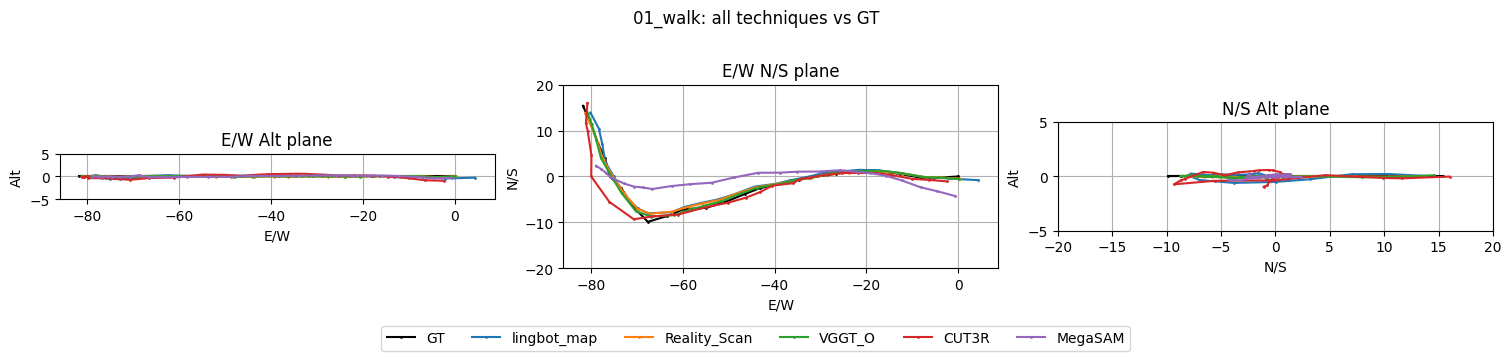

In [116]:
from matplotlib import pyplot as plt
def ortho_charts_multi(gt, traces, title="All techniques vs GT", out_path=None,
                        axis_lims={1: 5, 2: 20}):
    views = [("E/W", "Alt", 0, 1), ("E/W", "N/S", 0, 2), ("N/S", "Alt", 2, 1)]
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.5), constrained_layout=True)
    colors = plt.cm.tab10.colors
    dot_size = 1
    for ax, (xl, yl, xi, yi) in zip(axes, views):
        ax.plot(gt[:, xi], gt[:, yi], "o-", color="black", label="GT", markersize=dot_size)
        for i, (label, pts) in enumerate(traces.items()):
            ax.plot(pts[:, xi], pts[:, yi], "o-", color=colors[i % len(colors)], label=label, markersize=dot_size)
        ax.set_xlabel(xl); ax.set_ylabel(yl)
        ax.set_title(f"{xl} {yl} plane")
        if xi in axis_lims:
            ax.set_xlim(-axis_lims[xi], axis_lims[xi])
        if yi in axis_lims:
            ax.set_ylim(-axis_lims[yi], axis_lims[yi])
        ax.set_aspect("equal", adjustable="box")
        ax.grid(True)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="outside lower center", ncol=len(labels))
    fig.suptitle(title)
    if out_path is not None:
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()




ortho_charts_multi(
    gt_trace, aligned_traces,
    title=f"{case_name}: all techniques vs GT",
    out_path=out_dir / f"{case_name}_all_techniques_combined.png",
)


TROPEA CAFE!


In [ ]:
##I need to get the 